## Load libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import unyt

import os
from glob import glob
from pathlib import Path

# For Swift Emulator training and validation
import swiftemulator as se
from swiftemulator.design import latin
from swiftemulator.io.swift import load_parameter_files
from swiftemulator.emulators import gaussian_process, gaussian_process_bins, gaussian_process_mcmc, gaussian_process_one_dim, linear_model, multi_gaussian_process
from swiftemulator.mean_models.polynomial import PolynomialMeanModel
from swiftemulator.sensitivity import basic, cross_check, cross_check_bins
from swiftemulator.mocking import mock_sweep


# For reading in simulation observables as Velociraptor HDF5 files
from velociraptor.observations import load_observation, load_observations


# For saving emulator for later use
import dill

## Load simulated data (galaxy functions, scaling relations, ...)

In [2]:
snap_prefix = 'simba_s25n256'  # eg. 'simba_s12.5n128'


# Main directory where calibration runs have been performed - Adjust this for whatever I am using
root_dir = '/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x'

# entropy_venv_4stlock@nia-login03:/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0000$ 

# Subdirectory that holds actual calibration runs
cali_dir = 'calibrations'

# Name of simulation observable, eg. 'gsmf'

obs_name = 'gsmf_log_data_0015'
# obs_name = 'gsmfv2_log_data_0015'
# obs_name = 'gsmf_log_data_0015'
# obs_name = 'gsmf_log_data_min10gal_0015'
# obs_name = 'bhmsm_binned_log_median_0015'

# obs_name = 'bhmsm_binned_log_median_min10gal_0015'
# obs_name = 'bhmsm_kh13_log_fit_0015'
# obs_name = 'bhmsm_log_data_0015'
# obs_name = 'csfh_log_data'  # eg. 'gsmf'
# obs_name = 'csfh_binned_log_median'
# obs_name = 'quenched_fraction_0015'
# obs_name = 'massive_quenched_fraction_0015'
# obs_name = 'quenched_fraction_v2_0015'
# obs_name = 'lowMstar11_quenched_fraction_v2_0015'
# obs_name = 'ssfr_hist_bin_0_0015'

In [4]:
sim_paths = [Path(x) for x in glob(os.path.join(root_dir, cali_dir, 'cali_*', snap_prefix+'_'+obs_name+'.hdf5')) 
            if os.path.exists(x)]
cali_dirs = [Path(x) for x in glob(os.path.join(root_dir, cali_dir, 'cali_*')) 
            if os.path.exists(os.path.join(x, snap_prefix+'_'+obs_name+'.hdf5'))]

cali_dirnames = {dirname.stem: dirname for dirname in cali_dirs}
cali_list = [dirname.stem for dirname in cali_dirs]
print(sim_paths)
print(cali_list)
print(len(cali_list))

[PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0018/simba_s25n256_gsmf_log_data_0015.hdf5'), PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0002/simba_s25n256_gsmf_log_data_0015.hdf5'), PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0030/simba_s25n256_gsmf_log_data_0015.hdf5'), PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0000/simba_s25n256_gsmf_log_data_0015.hdf5'), PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0004/simba_s25n256_gsmf_log_data_0015.hdf5'), PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0019/simba_s25n256_gsmf_log_data_0015.hdf5'), PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0007/simba_s25n256_gsmf_log_data_0015.hdf5'), PosixPath('/scratch/b/babul/stlock/swimba_s25n256_ps2020_32x/calibrations/cali_0015/simba_s25n256_gsmf_log_data_0015.hdf5'),

In [5]:
sim_dict = {}
thin = 1

for cali, sim_path in zip(cali_list, sim_paths):
    print(cali)
    sim_file = sim_path
    sim_data = load_observations(sim_file)[0]

    try:
        sim_data = load_observations(sim_file)[0]
    except:
        print('Failed')
        continue

    # Load simulation observable data
    
    x_ = sim_data.x.value
    y_ = sim_data.y.value
    y_err_ = sim_data.y_scatter.value

    
    # Sanitize data of -inf, +inf, NaN values
    # Data for different simulations may have different array lengths
    isfinite = np.isfinite(x_)
    isfinite_err = np.resize(isfinite, np.shape(y_err_))
    x_ = x_[isfinite]
    y_ = y_[isfinite]
    y_err_copy = y_err_[isfinite_err]
    if (y_err_copy.ndim != y_err_.ndim):
        y_err_ = y_err_copy.reshape(y_err_.ndim, -1)
    else:
        y_err_ = y_err_copy
    

    isfinite = np.isfinite(y_)
    isfinite_err = np.resize(isfinite, np.shape(y_err_))
    x_ = x_[isfinite]
    y_ = y_[isfinite]
    y_err_copy = y_err_[isfinite_err]
    if (y_err_copy.ndim != y_err_.ndim):
        y_err_ = y_err_copy.reshape(y_err_.ndim, -1)
    else:
        y_err_ = y_err_copy
    
    
    # Get 1D errors
    y_err_arr = np.array(y_err_)
    if (y_err_arr.ndim!=1):
        mean_y_err_ = np.nanmean(y_err_arr, axis=0)
        max_y_err_ = np.nanmax(y_err_arr, axis=0)
    else:
        mean_y_err_ = y_err_arr
        max_y_err_ = y_err_arr
    
    
    sim_dict[cali] = {'x':x_[::thin], 'y':y_[::thin],
                      'y_err':y_err_, 'mean_y_err':mean_y_err_[::thin], 'max_y_err':max_y_err_[::thin], 
                      'sim_data':sim_data}

cali_0018
cali_0002
cali_0030
cali_0000
cali_0004
cali_0019
cali_0007
cali_0015
cali_0003
cali_0012
cali_0022
cali_0009
cali_0029
cali_0026
cali_0016
cali_0017
cali_0008
cali_0023
cali_0021
cali_0031
cali_0025
cali_0024
cali_0013
cali_0005
cali_0027
cali_0028
cali_0001
cali_0020
cali_0006
cali_0014


In [6]:
sim_data = load_observations(sim_file)[0]
sim_info = {
    'X_LABEL':sim_data.x_description,
    'Y_LABEL':sim_data.y_description,
    'name':sim_data.name,
    'x_units':sim_data.x_units,
    'y_units':sim_data.y_units,
    'comment':sim_data.comment,
    'z':sim_data.redshift,
    'z_lo':sim_data.redshift_lower,
    'z_hi':sim_data.redshift_upper,
    'plot_as':sim_data.plot_as,
}

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.73820744 -1.70065809 -1.9373814  -2.27468936 -2.50316869 -2.71402205
 -2.96389953 -3.35387061 -4.39526329]
yerr:  [0.23999178 0.23323252 0.23571909 0.29416678 0.26356914 0.41747029
 0.27767477 0.25879013 0.52708143]


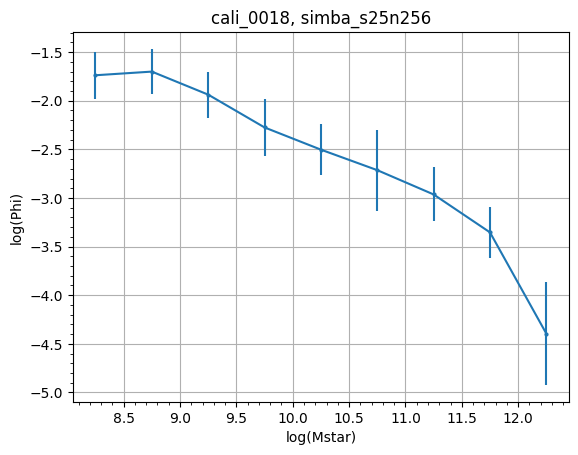

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.48039147 -1.32782045 -1.55578524 -1.84872063 -2.13758472 -2.34218485
 -2.6549006  -3.0942333  -4.0942333 ]
yerr:  [0.21830124 0.21488169 0.22502543 0.23648672 0.26604089 0.30138144
 0.3063443  0.29508156 0.40282768]


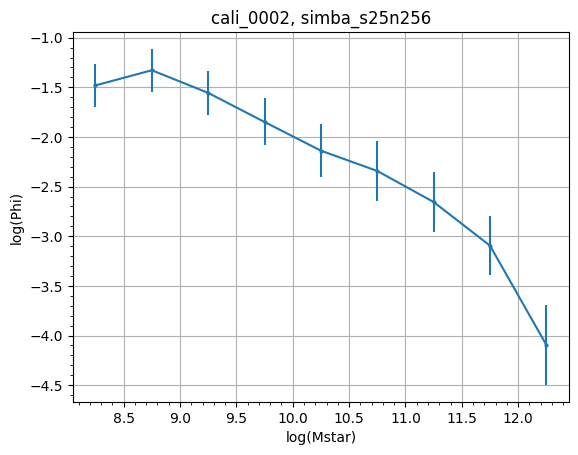

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75]
y:  [-1.72224238 -1.66772203 -1.9358708  -2.21057186 -2.54400494 -2.67925995
 -2.94810526 -3.31608205]
yerr:  [0.2222671  0.24187824 0.23794668 0.3145641  0.26085616 0.34745974
 0.32178119 0.21476601]


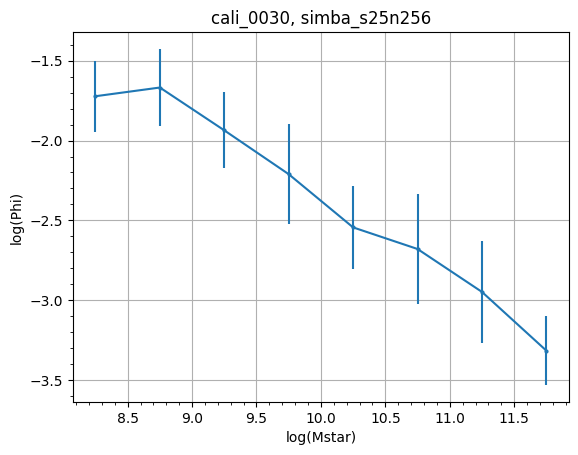

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.86892401 -1.91238971 -2.17777935 -2.35783679 -2.54400494 -2.8154797
 -2.99732328 -3.61711204 -4.39526329]
yerr:  [0.29265368 0.19015598 0.26937559 0.34837578 0.27855331 0.36696107
 0.21830714 0.22029805 0.52708143]


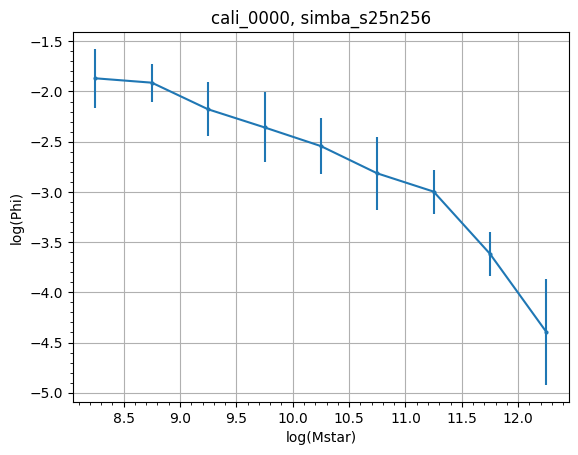

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.40182706 -1.16226718 -1.38453943 -1.62959474 -1.9512185  -2.22500158
 -2.56918849 -3.01505205 -4.39526329]
yerr:  [0.257681   0.20200182 0.23023007 0.22039902 0.21501401 0.29318408
 0.39889922 0.35205618 0.52708143]


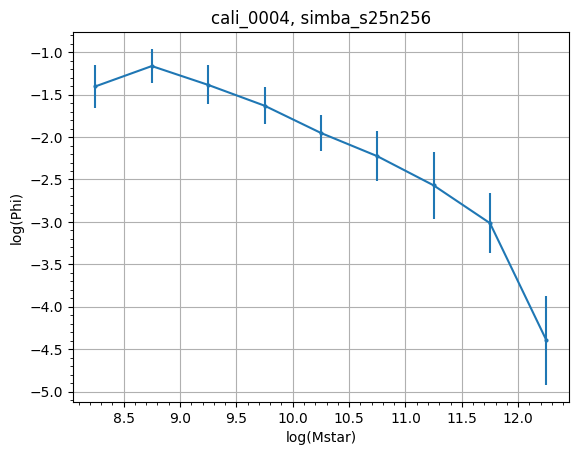

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.72040215 -1.62147685 -1.89283617 -2.14975062 -2.46076484 -2.67925995
 -2.98028994 -3.31608205 -4.0942333 ]
yerr:  [0.24760182 0.21828312 0.2346422  0.20619356 0.32217172 0.30847274
 0.30806825 0.24833165 0.40282768]


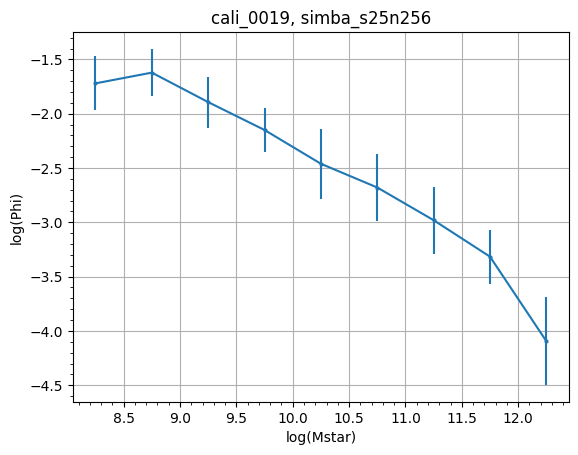

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.63408748 -1.52544508 -1.75677403 -2.04891032 -2.37407399 -2.57571936
 -2.82706157 -3.11650969 -4.39526329]
yerr:  [0.23493705 0.23728103 0.19084794 0.25086077 0.35789809 0.24972668
 0.40772892 0.27219573 0.52708143]


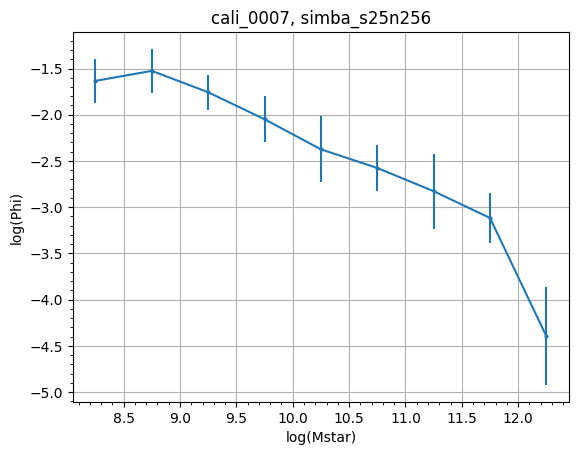

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.84381329 -1.83416191 -2.06688369 -2.37407399 -2.61711204 -2.73250546
 -3.073044   -3.44102078 -4.39526329]
yerr:  [0.25313825 0.23526083 0.26026887 0.42960645 0.27552884 0.37275672
 0.22665609 0.24428954 0.52708143]


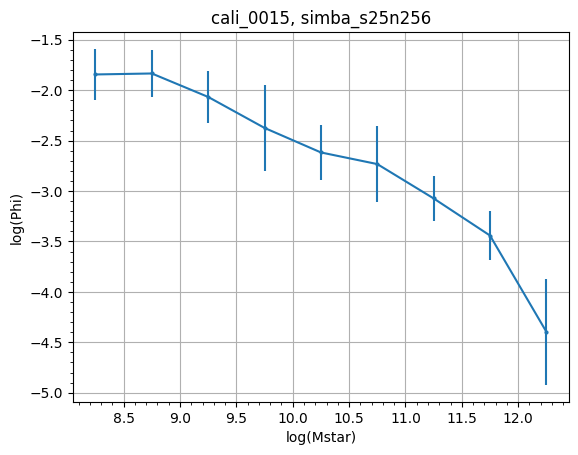

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.57374976 -1.44636153 -1.69283276 -1.98028994 -2.277992   -2.52020203
 -2.72316543 -3.19114331 -3.91814204]
yerr:  [0.20548554 0.22571722 0.24042815 0.19790968 0.35548286 0.28772834
 0.4123138  0.2275153  0.32465021]


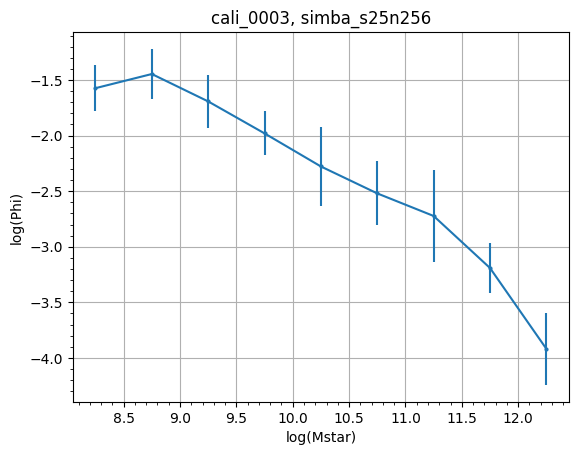

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.85618719 -1.9358708  -2.17777935 -2.34994031 -2.5564142  -2.7932033
 -3.01505205 -3.61711204 -4.39526329]
yerr:  [0.27695861 0.25156409 0.27800301 0.3491475  0.25679895 0.37992089
 0.21135781 0.22029805 0.52708143]


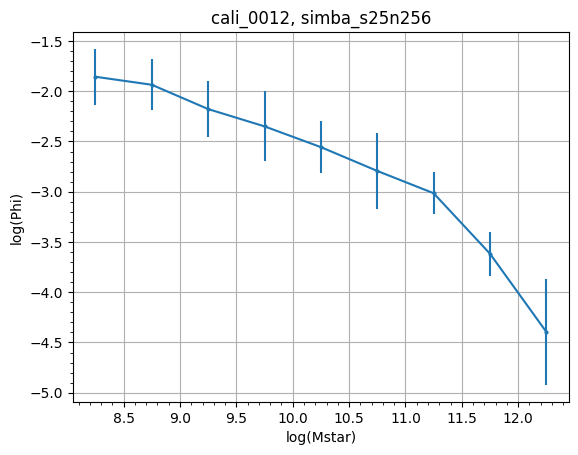

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.5816823  -1.46380542 -1.68769312 -2.01144793 -2.31608205 -2.57571936
 -2.72316543 -3.13999079 -4.39526329]
yerr:  [0.21757294 0.2342335  0.21642301 0.22332379 0.28029935 0.3187378
 0.41081153 0.328754   0.52708143]


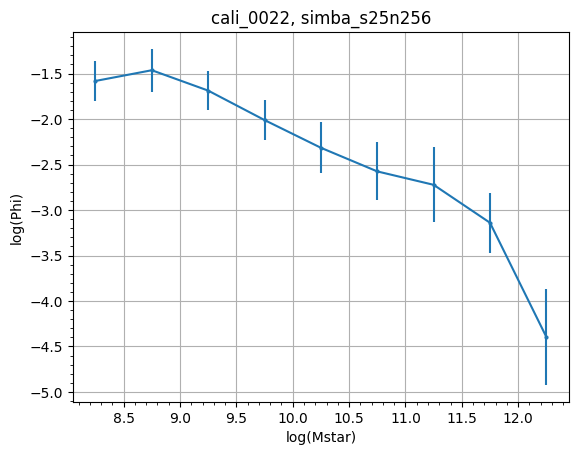

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.84016884 -1.80087074 -2.07511701 -2.34604527 -2.50877257 -2.80419868
 -3.01505205 -3.69629329 -4.0942333 ]
yerr:  [0.28985634 0.24467491 0.21983945 0.36836527 0.23748074 0.2601751
 0.32854905 0.2959787  0.40282768]


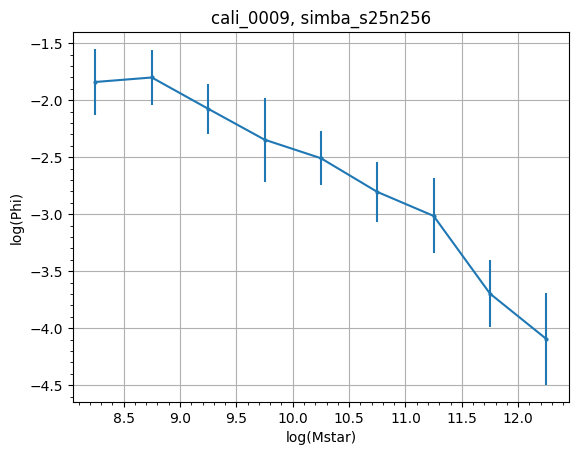

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.43242061 -1.18494477 -1.41662634 -1.65966439 -1.94501418 -2.2369008
 -2.56275438 -3.073044   -4.39526329]
yerr:  [0.23049999 0.20371966 0.23859159 0.22176814 0.24738955 0.25184486
 0.35641593 0.29625698 0.52708143]


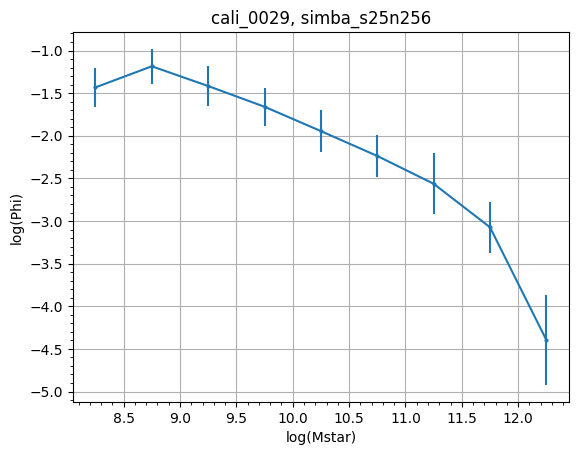

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.82588938 -1.8574442  -2.12809156 -2.35387061 -2.54400494 -2.7932033
 -3.01505205 -3.4921733  -4.39526329]
yerr:  [0.26685321 0.23235639 0.22575475 0.44171546 0.23982243 0.32539314
 0.2629056  0.23215984 0.52708143]


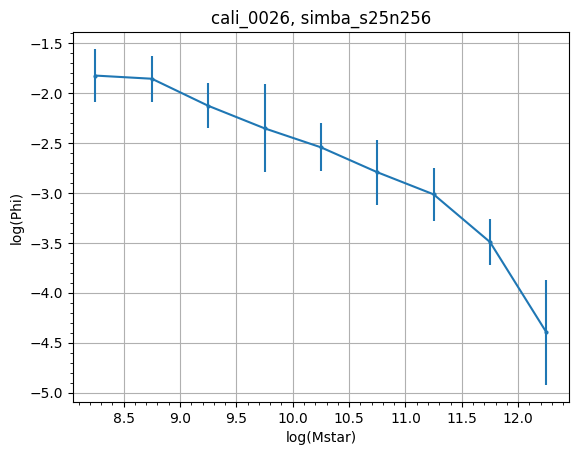

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.68684239 -1.61279067 -1.85618719 -2.14241026 -2.47098401 -2.62441128
 -3.073044   -3.11650969 -4.39526329]
yerr:  [0.21786138 0.22337655 0.22635515 0.24972633 0.24763713 0.33041558
 0.31802364 0.27219573 0.52708143]


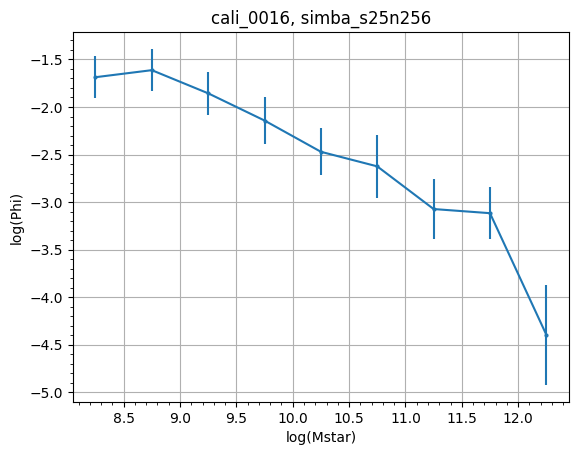

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.85870485 -1.96551101 -2.15973484 -2.32707743 -2.60993346 -2.76179484
 -3.073044   -3.61711204 -4.0942333 ]
yerr:  [0.26811055 0.24091045 0.29378171 0.4493921  0.22900261 0.38704278
 0.22833257 0.22029805 0.40282768]


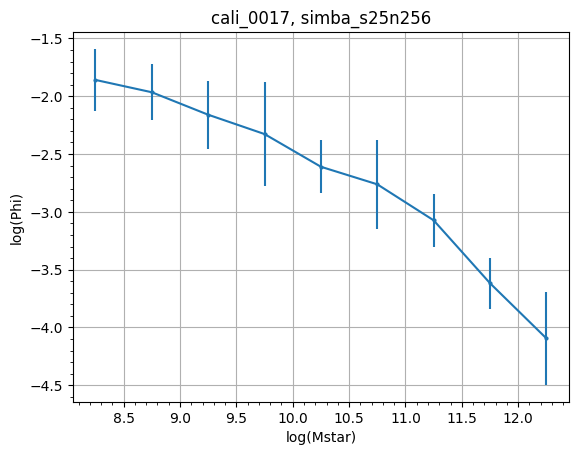

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75]
y:  [-1.7772152  -1.762806   -2.00787347 -2.34604527 -2.5144497  -2.74205078
 -2.96389953 -3.69629329]
yerr:  [0.25487875 0.21077796 0.26429068 0.30648975 0.25139911 0.35264752
 0.33948475 0.28927597]


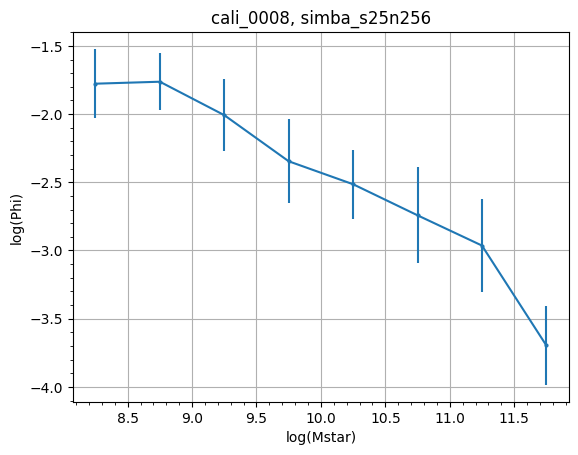

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.85493382 -1.89695274 -2.10079707 -2.41299206 -2.5379308  -2.8154797
 -3.0942333  -3.35387061 -4.39526329]
yerr:  [0.28410043 0.18629588 0.25095463 0.41499284 0.309369   0.37942324
 0.27875232 0.25879013 0.52708143]


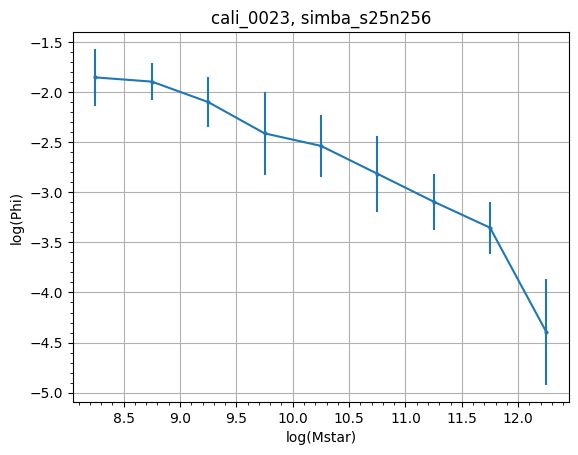

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.51273875 -1.40138638 -1.61422635 -1.89283617 -2.21628634 -2.44102078
 -2.70506721 -3.073044   -4.0942333 ]
yerr:  [0.2303253  0.21093636 0.2377638  0.18854192 0.26284972 0.3102549
 0.40483795 0.28664269 0.40282768]


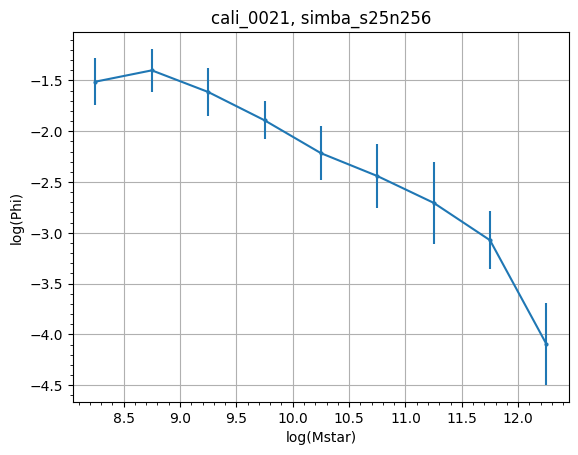

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75]
y:  [-1.89011331 -1.97862278 -2.1328122  -2.3996281  -2.4921733  -2.82706157
 -3.01505205 -3.44102078]
yerr:  [0.2481367  0.21285326 0.23725214 0.42140442 0.27490313 0.3765603
 0.23449654 0.22199418]


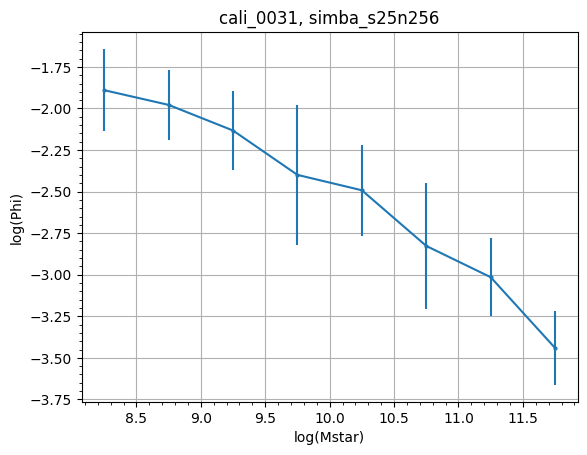

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.43100366 -1.12018239 -1.34449698 -1.5666034  -1.9195921  -2.15973484
 -2.57571936 -2.98028994 -4.0942333 ]
yerr:  [0.23692367 0.20825686 0.23117218 0.21840169 0.21012042 0.31946983
 0.26535806 0.31059971 0.40282768]


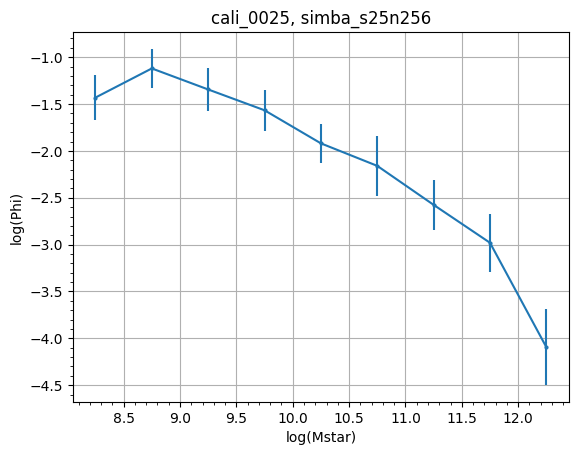

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.44832002 -1.31355602 -1.54156508 -1.80531369 -2.08776725 -2.34604527
 -2.62441128 -3.11650969 -4.0942333 ]
yerr:  [0.23312326 0.21224022 0.23643918 0.21133097 0.26789439 0.30420165
 0.37014303 0.25107874 0.40282768]


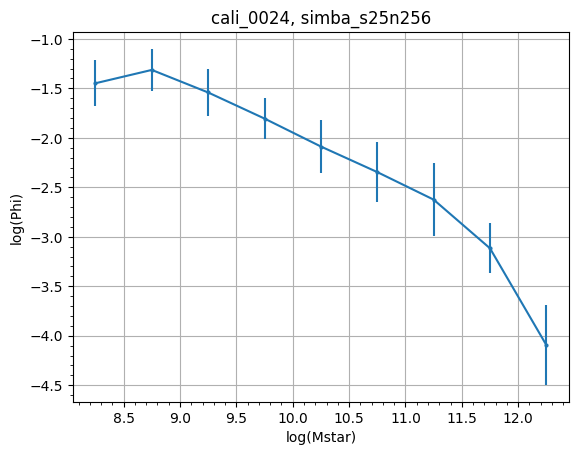

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.7942904  -1.7557768  -2.04115485 -2.27141165 -2.5144497  -2.74205078
 -3.03353546 -3.4921733  -4.39526329]
yerr:  [0.20177343 0.23631948 0.24019906 0.26442396 0.26065623 0.34245679
 0.24180955 0.23215984 0.52708143]


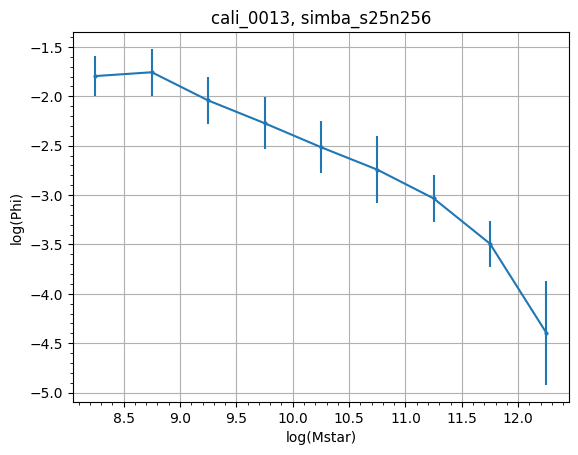

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.74495577 -1.71674491 -1.976962   -2.23992725 -2.5564142  -2.73250546
 -2.99732328 -3.39526329 -4.39526329]
yerr:  [0.25696341 0.23980435 0.23436004 0.26829613 0.23202204 0.25032859
 0.3483746  0.21679159 0.52708143]


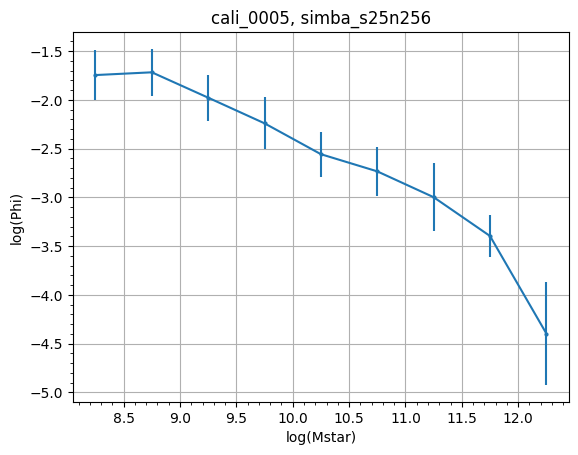

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.86634659 -1.84259508 -2.11422992 -2.39094192 -2.5144497  -2.76179484
 -3.073044   -3.44102078 -4.39526329]
yerr:  [0.26206758 0.23448858 0.25228425 0.3498905  0.24450953 0.39072795
 0.21697622 0.24428954 0.52708143]


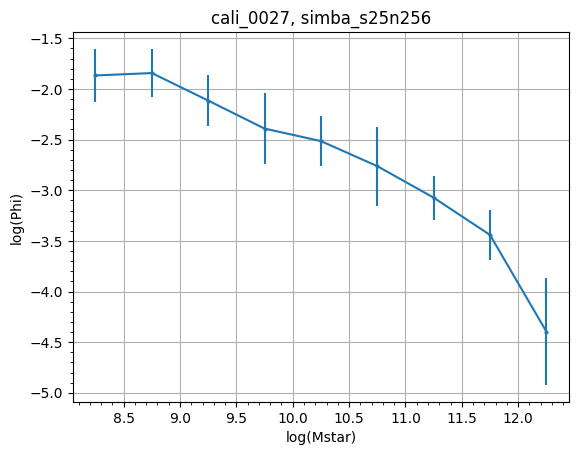

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75]
y:  [-1.87412521 -1.92104703 -2.14975062 -2.31608205 -2.57571936 -2.7932033
 -3.01505205 -3.55016525]
yerr:  [0.26286819 0.19716197 0.28824776 0.36234361 0.30342911 0.24422992
 0.3520504  0.21908233]


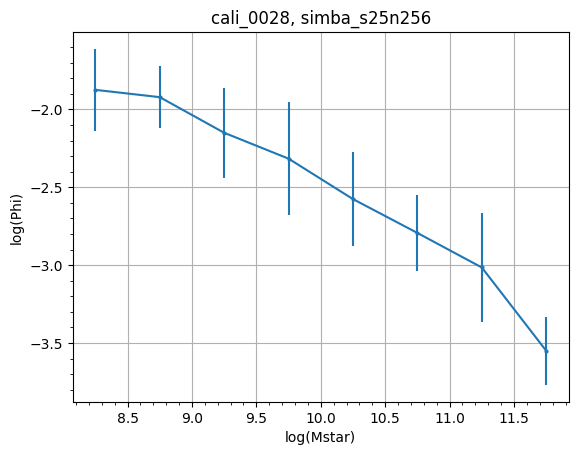

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.63333545 -1.55078612 -1.80755233 -2.07511701 -2.40849156 -2.60993346
 -2.85119525 -3.19114331 -4.0942333 ]
yerr:  [0.24115736 0.22370888 0.23774375 0.23822712 0.33959648 0.34273492
 0.32592978 0.26129753 0.40282768]


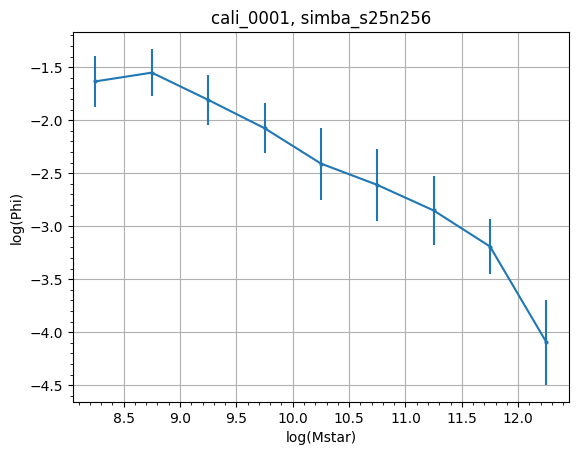

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.4522637  -1.09925662 -1.29077618 -1.55704407 -1.86250891 -2.12575035
 -2.5144497  -3.073044   -4.39526329]
yerr:  [0.26689723 0.20151605 0.22751554 0.21936755 0.217947   0.29083535
 0.3574872  0.32502358 0.52708143]


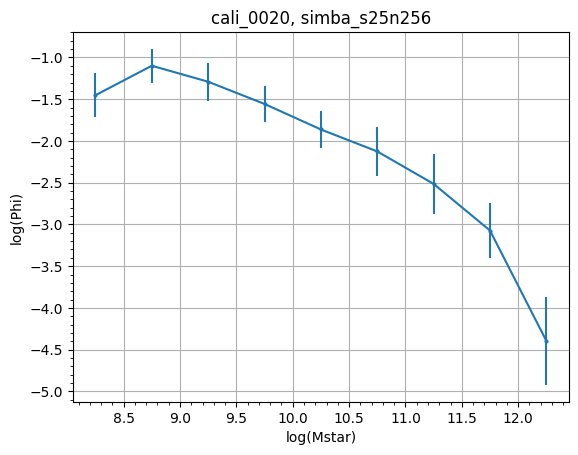

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.43479251 -1.24144843 -1.47461829 -1.73062132 -2.00081161 -2.29835328
 -2.56918849 -2.98028994 -4.39526329]
yerr:  [0.21790367 0.21249794 0.21981153 0.23346297 0.23435498 0.32927414
 0.28744263 0.36651726 0.52708143]


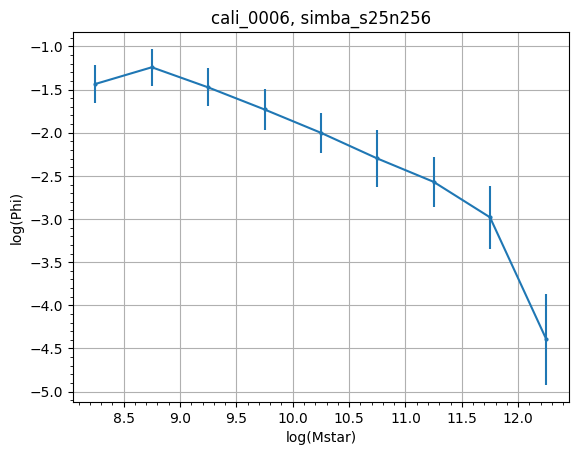

x:  [ 8.25  8.75  9.25  9.75 10.25 10.75 11.25 11.75 12.25]
y:  [-1.47775778 -1.10545145 -1.22912932 -1.49818629 -1.80643157 -2.05880356
 -2.50877257 -3.03353546 -4.39526329]
yerr:  [0.28363032 0.2133569  0.20524159 0.2241053  0.22394192 0.29389737
 0.29149155 0.35225724 0.52708143]


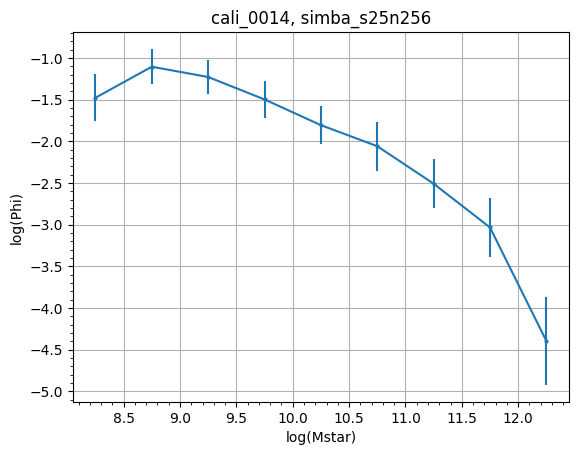

In [7]:
# Plot the observable to check it worked

thin_ = 1
# thin_ = 10 # for CSFH

for cali in sim_dict:
    print("x: ", sim_dict[cali]['x'])
    print("y: ", sim_dict[cali]['y'])
    print("yerr: ", sim_dict[cali]['max_y_err'])    
    
    plt.clf()
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.title(r'%s, %s' % (cali, snap_prefix))
    plt.grid()
    plt.minorticks_on()
    plt.errorbar(sim_dict[cali]['x'][::thin_], sim_dict[cali]['y'][::thin_], yerr=sim_dict[cali]['max_y_err'][::thin_], 
                 fmt='o-', markersize=2)
    # plt.scatter(sim_dict[cali]['x'][::thin_], sim_dict[cali]['y'][::thin_], s=2)
    plt.show()

## Specify the model parameters and values

In [16]:
parameter_files = [Path(os.path.join(cali_dir, cali+'.yml')) for cali_dir, cali in zip(cali_dirs, cali_list)]
parameter_filenames = {filename.stem: filename for filename in parameter_files}

In [17]:
## Set this to what you ran the simulations with

model_specification, model_parameters = load_parameter_files(
    filenames=parameter_filenames,
    parameters=[
         "SIMBAFeedback:FIRE_velocity_normalization",
        "SIMBAAGN:torque_accretion_norm",
        "SIMBAAGN:jet_mass_min_Msun"
    ],
    log_parameters=[
        "SIMBAAGN:jet_mass_min_Msun",
        "SIMBAAGN:torque_accretion_norm"
    ],
    parameter_printable_names=[
            r"$v_{a}$",
        r"$\varepsilon_{\rm torque}$",
        r"$\log_{10}$ $M_{\rm BH, lim}/M_{\rm \odot}$"
        #"$v_{a}",
        #"$\varepsilon_{\\rm torque}$",
        #"$\\log_{10}$ $M_{\\rm BH, lim}/M_{\\rm \odot}$"
    ],
)

In [ ]:
modelvalues = {}

## Choose a min and max x value to limit the emulator to when training

# these are mass bins (make range more specific)

# GSMF
# min_x_for_emulator = 6
min_x_for_emulator = 8.5  # Seems to be resolution limit
# min_x_for_emulator = 9
# min_x_for_emulator = 10
# max_x_for_emulator = 11
# max_x_for_emulator = 11.2
# max_x_for_emulator = 11.6
max_x_for_emulator = 15

# Mbh-M*
# min_x_for_emulator = 6
# min_x_for_emulator = 8.2
# min_x_for_emulator = 8.5
# min_x_for_emulator = 8.75
# min_x_for_emulator = 9
# min_x_for_emulator = 9.5
# min_x_for_emulator = 10
# max_x_for_emulator = 11
# max_x_for_emulator = 11.2
# max_x_for_emulator = 11.7
# max_x_for_emulator = 12
# max_x_for_emulator = 15

# Quenched Fraction
# min_x_for_emulator = 0
# max_x_for_emulator = 100

# sSFR Histogram
# min_x_for_emulator = -2.7
# max_x_for_emulator = 0
# max_x_for_emulator = 0.5

# CSFH
# min_x_for_emulator = -1
# max_x_for_emulator = 5

# If too many data points, will take very long to train emulator and use emulator to predict values
thin_ = 4
# thin_ = 10 # for CSHF

# rel_err = 0.02 # for Mbh-M*
rel_err = 0.05 # for CSFH

for cali in model_parameters.model_parameters:
    independent = sim_dict[cali]['x'][::thin_]
    dependent = sim_dict[cali]['y'][::thin_]
    
    # Must choose whether to specify own errorbars
    # or use maximum or mean errorbars (as swift emulator can only handle single value for errorbars)
#     dependent_error = np.abs(rel_err * dependent)
#    dependent_error = sim_dict[cali]['max_y_err'][::thin_]
    dependent_error = np.array([0]*len(dependent))

    range_condition = np.logical_and(independent>=min_x_for_emulator, independent<=max_x_for_emulator)
    
    modelvalues[cali] = {"independent": independent[range_condition],
                         "dependent": dependent[range_condition],
                         "dependent_error": dependent_error[range_condition]}

model_values = se.ModelValues(model_values=modelvalues)

In [25]:
## To check if there are any x bin values appearing only once
    # emulator needs more than one sample, cause it needs to compare
## This can make errors pop up when training the emulator, doing the parameter sensitivity analysis
## and performing the cross-check validation

comb_ = np.array([])
for key, val in model_values.model_values.items():
#     print(np.all(np.isfinite(val['independent'])))
#     print(np.all(np.isfinite(val['dependent'])))
#     print(np.all(np.isfinite(val['dependent_error'])))
#     print(max(val['independent']))
    comb_ = np.concatenate((comb_, val['independent']))
#     comb_ = np.append(comb_, val['independent'])
#     comb_ = np.append(comb_, max(val['independent']))
    
# Find unique values and their counts
unique_values, counts = np.unique(comb_, return_counts=True)
print("Unique x values:", unique_values)
print("Number of times:", counts)

# Find values that appear only once
values_appearing_once = unique_values[counts == 1]

# Print the values that appear only once
print("x values appearing only once:", values_appearing_once)

Unique x values: [10.25 12.25]
Number of times: [30 26]
x values appearing only once: []


## Model Parameter Features

In [26]:
print(model_parameters)
print(model_specification)

ModelParameters(model_parameters={'cali_0018': {'SIMBAFeedback:FIRE_velocity_normalization': 2.8282233935432157, 'SIMBAAGN:torque_accretion_norm': -5.845839622213301, 'SIMBAAGN:jet_mass_min_Msun': 7.428153470375958}, 'cali_0002': {'SIMBAFeedback:FIRE_velocity_normalization': 1.4976705929308105, 'SIMBAAGN:torque_accretion_norm': -5.555169535796033, 'SIMBAAGN:jet_mass_min_Msun': 7.078304357678525}, 'cali_0030': {'SIMBAFeedback:FIRE_velocity_normalization': 2.711742113870128, 'SIMBAAGN:torque_accretion_norm': -4.427320927554158, 'SIMBAAGN:jet_mass_min_Msun': 8.61872451926755}, 'cali_0000': {'SIMBAFeedback:FIRE_velocity_normalization': 4.40791943412237, 'SIMBAAGN:torque_accretion_norm': -7.1605075148915205, 'SIMBAAGN:jet_mass_min_Msun': 7.646993431786365}, 'cali_0004': {'SIMBAFeedback:FIRE_velocity_normalization': 1.018032377850988, 'SIMBAAGN:torque_accretion_norm': -6.008110896933457, 'SIMBAAGN:jet_mass_min_Msun': 7.496316439539282}, 'cali_0019': {'SIMBAFeedback:FIRE_velocity_normalizatio

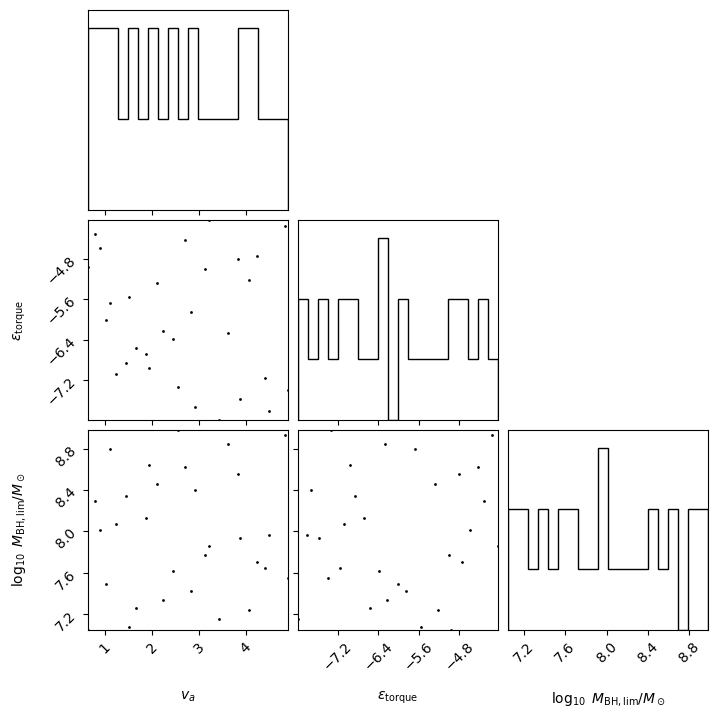

In [27]:
model_parameters.plot_model(model_specification)

# x axis is wind speed, y axis is as labeled

## Train emulator

In [28]:
emulator = gaussian_process.GaussianProcessEmulator()  # Default, MAKE IT
# emulator = gaussian_process_mcmc.GaussianProcessEmulatorMCMC(mcmc_steps=1000, burn_in_steps=1, walkers=40, use_hyperparameter_error=False)  # With MCMC
# emulator = gaussian_process_bins.GaussianProcessEmulatorBins()  # Gaussian Process Emulator using an emulator for each bins
# emulator = gaussian_process_one_dim.GaussianProcessEmulator1D()  # Gaussian Process Emulator for emulating single values
# emulator = linear_model.LinearModelEmulator(lasso_model_alpha=0)  # Linear Model Emulator
# emulator = multi_gaussian_process.MultipleGaussianProcessEmulator()  # A gaussian process emulator that uses _multiple_ internal emulators to better predict functions that contain a ‘break’.
# polynomial_model = PolynomialMeanModel(degree=4)  # Polynomial mean model
# emulator = gaussian_process.GaussianProcessEmulator(mean_model=polynomial_model)  # Mean model

emulator.fit_model(model_specification=model_specification, #TRAIN IT
                            model_parameters=model_parameters,
                            model_values=model_values)
emulator.model_specification.sim_info = sim_info # LINK IT

#ALL TRAINING IS DONE HERE, ALL AFTER IS TO CHECK HOW WELL IT WORKED

## Make predictions and compare

x:  [10.25 12.25]
y:  [-2.50316858 -4.3952632 ]
yerr:  [1.25099930e-12 1.25011113e-12]
Slope:  [-0.9460473061106285]


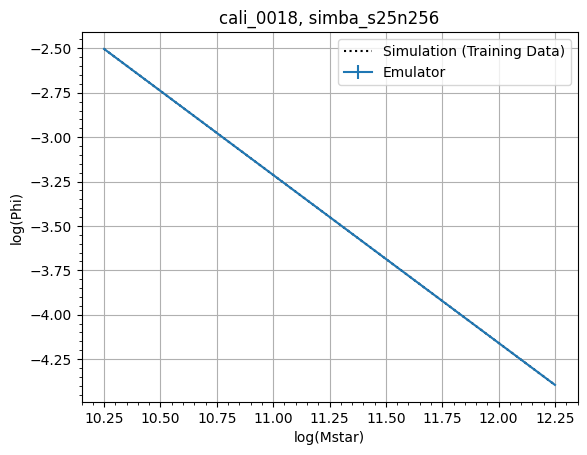

x:  [10.25 12.25]
y:  [-2.13281226 -4.3952632 ]
yerr:  [1.25055521e-12 1.24966704e-12]
Slope:  [-1.1312254667081874]


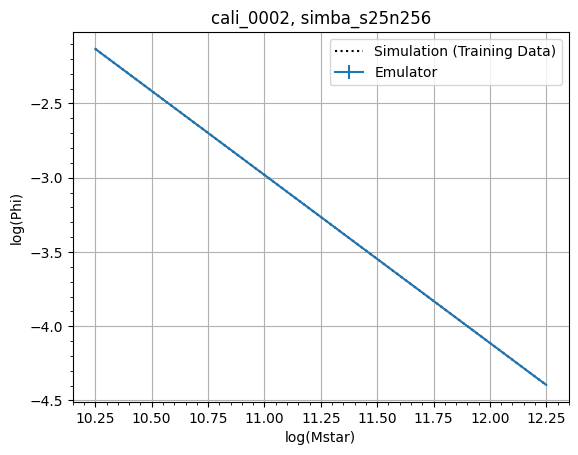

x:  [10.25]
y:  [-2.53194046]
yerr:  [1.25011113e-12]
Slope:  []


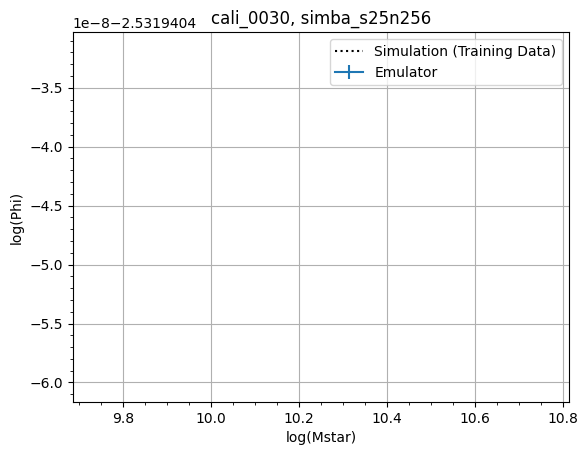

x:  [10.25 12.25]
y:  [-2.53194046 -4.3952632 ]
yerr:  [1.24922295e-12 1.25011113e-12]
Slope:  [-0.9316613674243079]


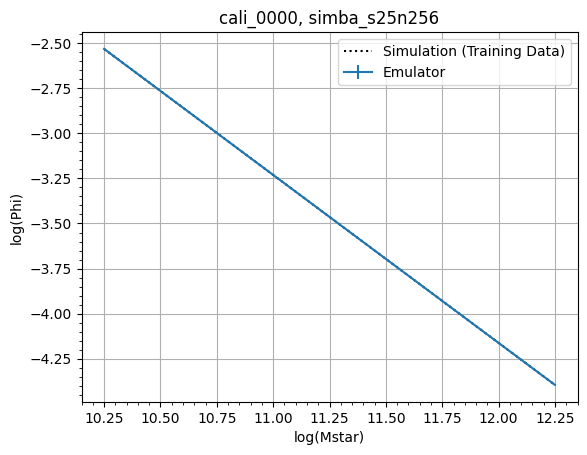

x:  [10.25 12.25]
y:  [-1.93738139 -4.39526319]
yerr:  [1.25011113e-12 1.24966704e-12]
Slope:  [-1.2289409041082138]


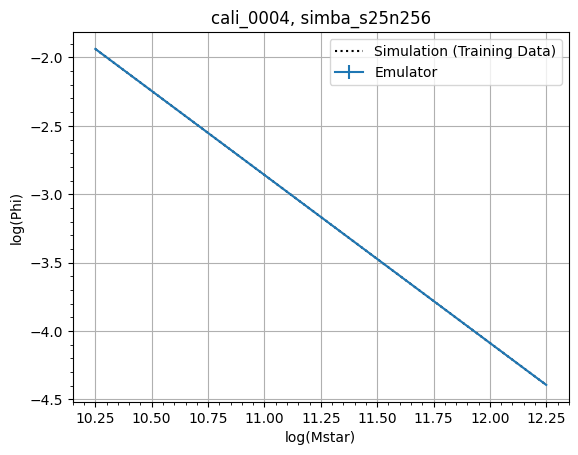

x:  [10.25 12.25]
y:  [-2.50316858 -4.09423351]
yerr:  [1.25055521e-12 1.24922295e-12]
Slope:  [-0.7955324649786917]


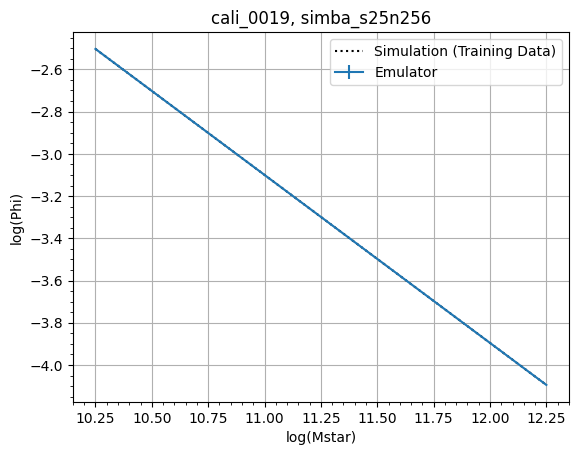

x:  [10.25 12.25]
y:  [-2.35783672 -3.91814208]
yerr:  [1.25055521e-12 1.24966704e-12]
Slope:  [-0.7801526784951704]


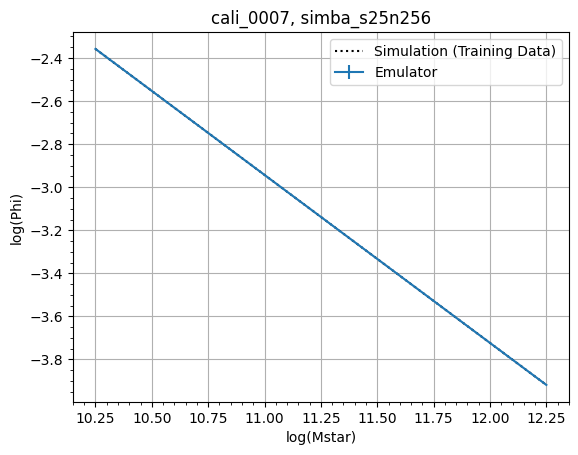

x:  [10.25 12.25]
y:  [-2.57571936 -4.09423351]
yerr:  [1.25055521e-12 1.25055521e-12]
Slope:  [-0.75925707816954]


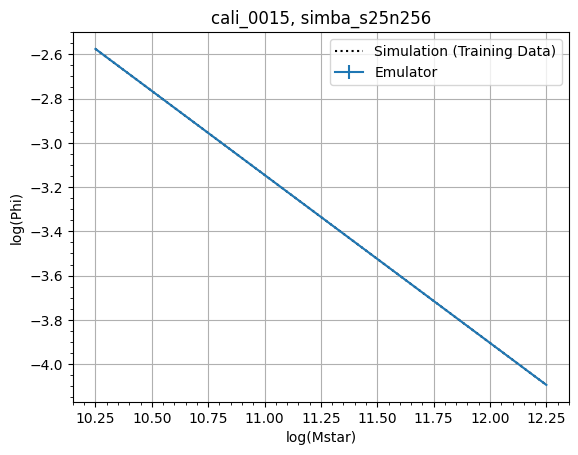

x:  [10.25 12.25]
y:  [-2.29145956 -4.09423351]
yerr:  [1.25011113e-12 1.25055521e-12]
Slope:  [-0.901386976283348]


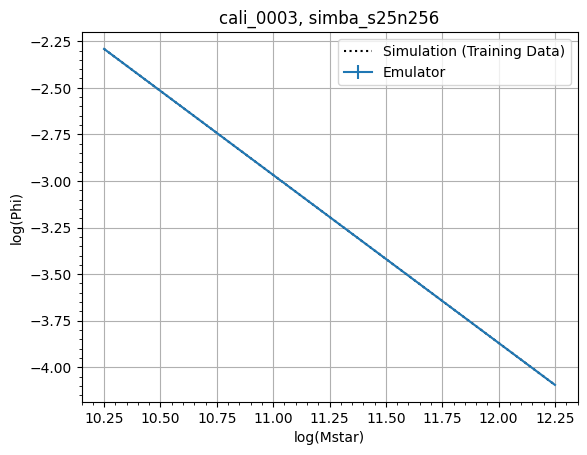

x:  [10.25 12.25]
y:  [-2.59592271 -4.3952632 ]
yerr:  [1.24877886e-12 1.25055521e-12]
Slope:  [-0.8996702432583952]


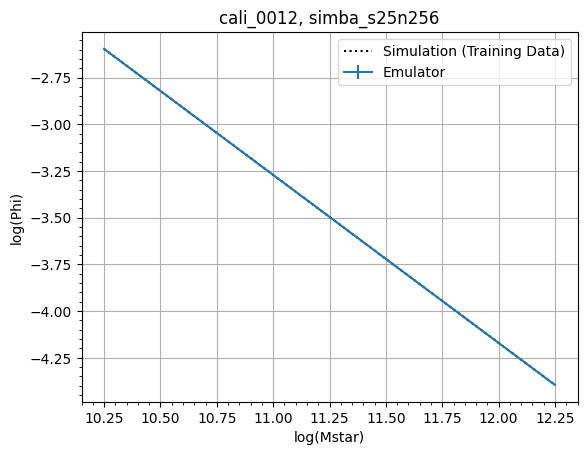

x:  [10.25 12.25]
y:  [-2.28467369 -4.3952632 ]
yerr:  [1.25099930e-12 1.25011113e-12]
Slope:  [-1.0552947521182006]


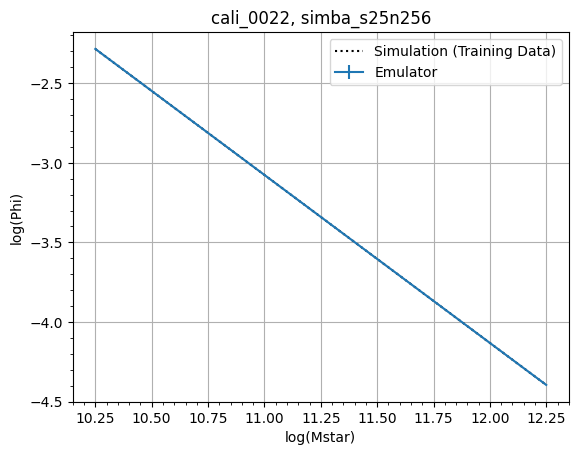

x:  [10.25 12.25]
y:  [-2.5144496 -4.3952632]
yerr:  [1.24922295e-12 1.24966704e-12]
Slope:  [-0.940406799308505]


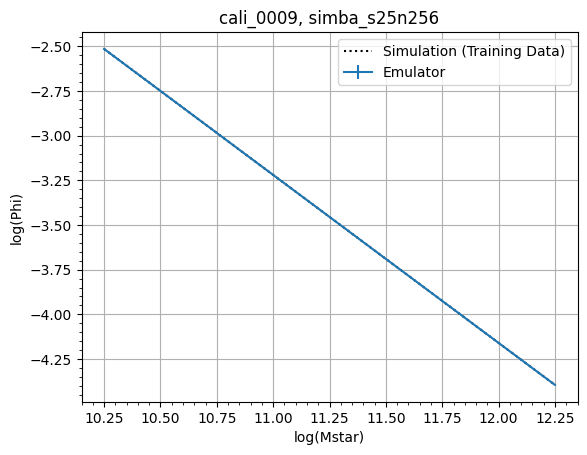

x:  [10.25 12.25]
y:  [-1.96875203 -4.3952632 ]
yerr:  [1.24922295e-12 1.24877886e-12]
Slope:  [-1.2132555842608959]


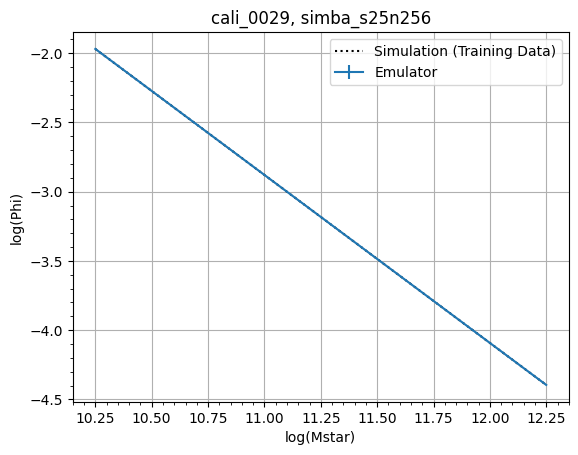

x:  [10.25 12.25]
y:  [-2.54400492 -4.3952632 ]
yerr:  [1.25011113e-12 1.24966704e-12]
Slope:  [-0.925629138948679]


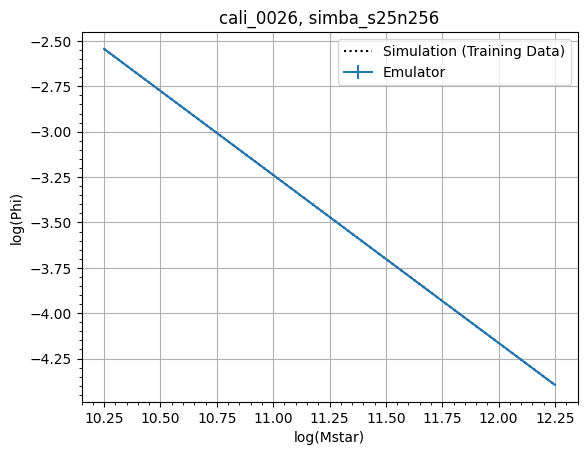

x:  [10.25 12.25]
y:  [-2.48144937 -4.39526319]
yerr:  [1.25011113e-12 1.24922295e-12]
Slope:  [-0.9569069146700002]


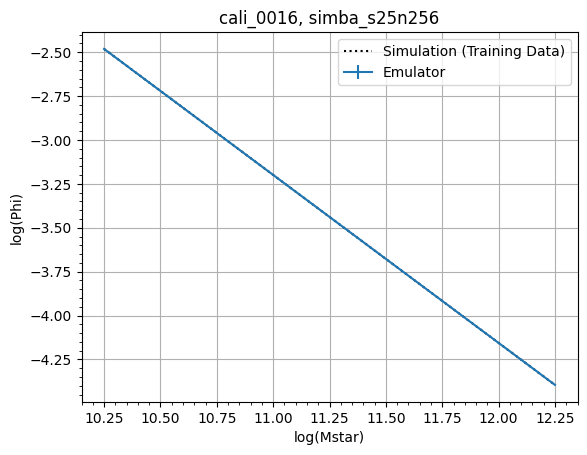

x:  [10.25 12.25]
y:  [-2.58908343 -4.3952632 ]
yerr:  [1.25055521e-12 1.25099930e-12]
Slope:  [-0.9030898809416845]


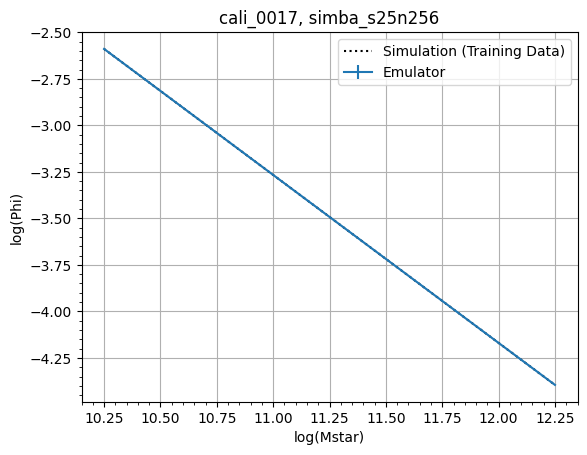

x:  [10.25]
y:  [-2.50316858]
yerr:  [1.25011113e-12]
Slope:  []


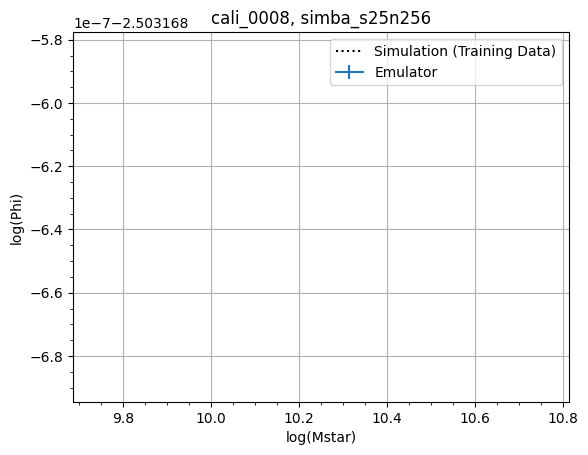

x:  [10.25 12.25]
y:  [-2.56918859 -4.3952632 ]
yerr:  [1.25011113e-12 1.25011113e-12]
Slope:  [-0.9130373001084813]


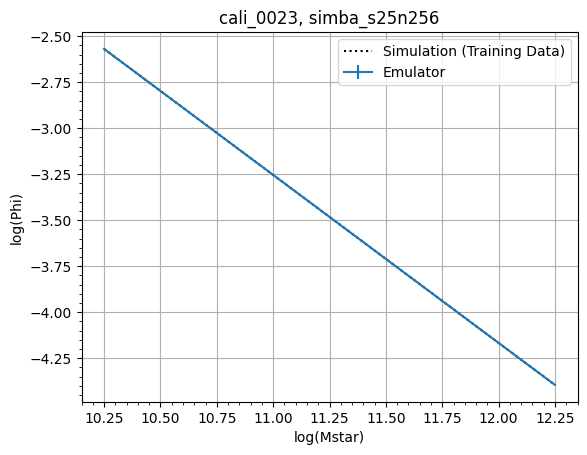

x:  [10.25 12.25]
y:  [-2.25538421 -4.09423351]
yerr:  [1.25144339e-12 1.24966704e-12]
Slope:  [-0.9194246530938841]


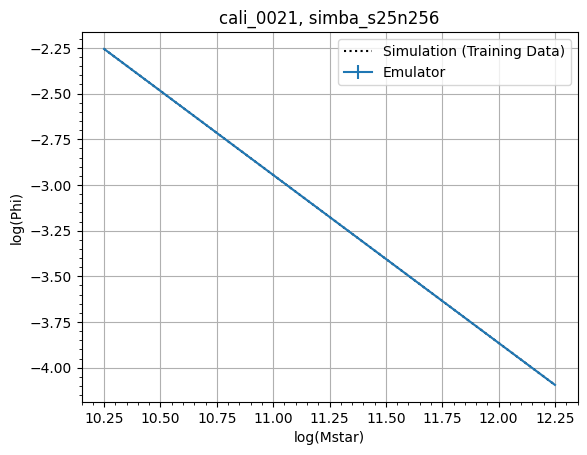

x:  [10.25]
y:  [-2.53793073]
yerr:  [1.25011113e-12]
Slope:  []


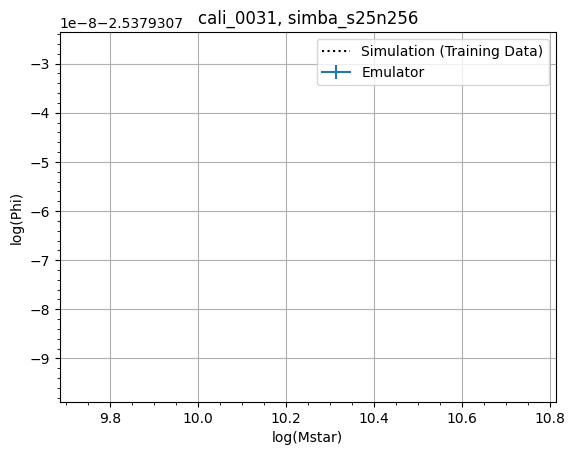

x:  [10.25 12.25]
y:  [-1.89557624 -4.3952632 ]
yerr:  [1.24966704e-12 1.25099930e-12]
Slope:  [-1.2498434782431644]


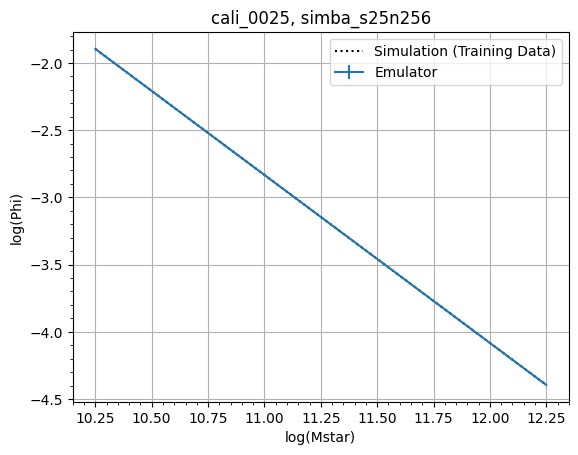

x:  [10.25 12.25]
y:  [-2.08776736 -4.39526319]
yerr:  [1.24966704e-12 1.25144339e-12]
Slope:  [-1.153747916148447]


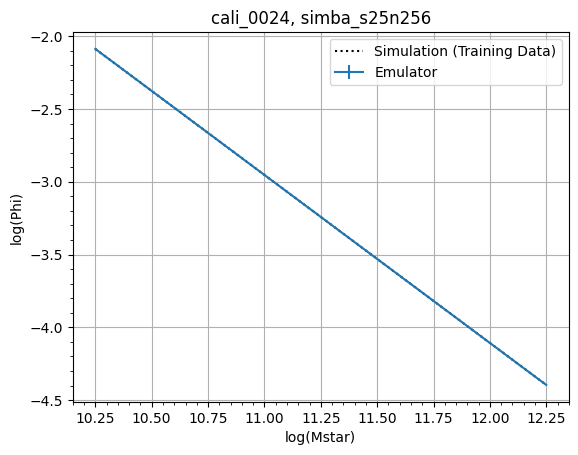

x:  [10.25 12.25]
y:  [-2.55016518 -4.3952632 ]
yerr:  [1.25011113e-12 1.25011113e-12]
Slope:  [-0.9225490093061381]


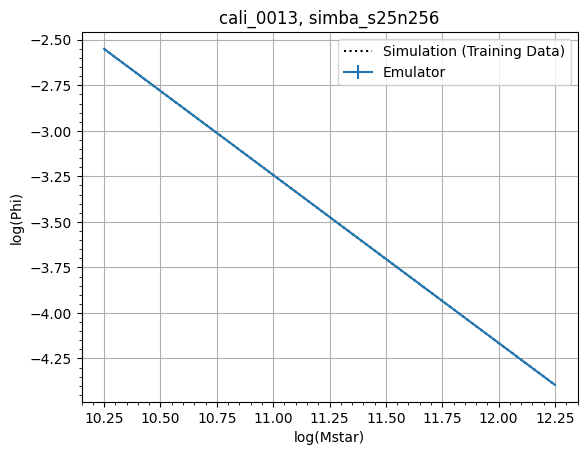

x:  [10.25 12.25]
y:  [-2.53194046 -4.09423351]
yerr:  [1.25099930e-12 1.24966704e-12]
Slope:  [-0.7811465263430648]


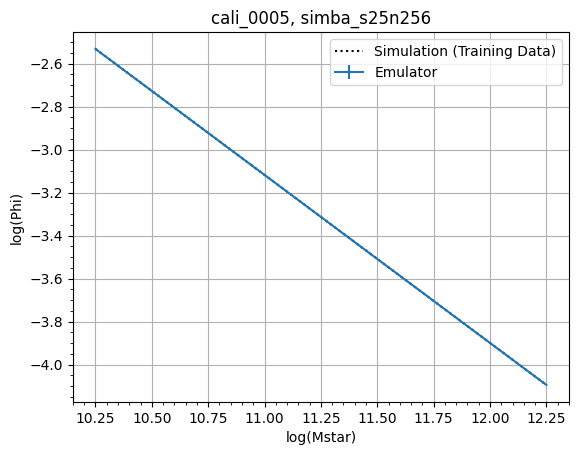

x:  [10.25 12.25]
y:  [-2.55016518 -4.3952632 ]
yerr:  [1.25011113e-12 1.25055521e-12]
Slope:  [-0.9225490093243565]


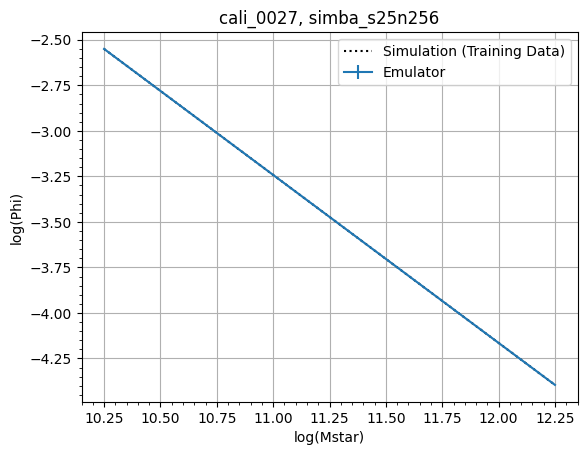

x:  [10.25]
y:  [-2.56275439]
yerr:  [1.25011113e-12]
Slope:  []


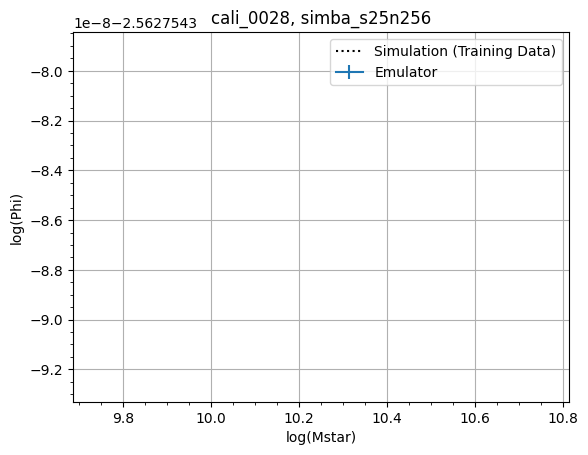

x:  [10.25 12.25]
y:  [-2.4175396 -4.3952632]
yerr:  [1.25011113e-12 1.24966704e-12]
Slope:  [-0.9888617992178155]


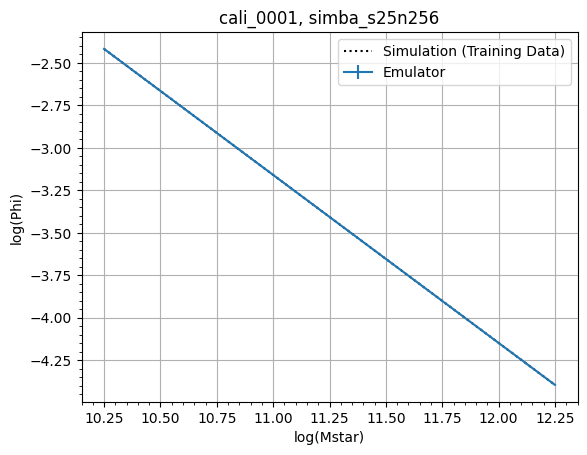

x:  [10.25 12.25]
y:  [-1.87412524 -4.39526319]
yerr:  [1.24966704e-12 1.25099930e-12]
Slope:  [-1.2605689763696653]


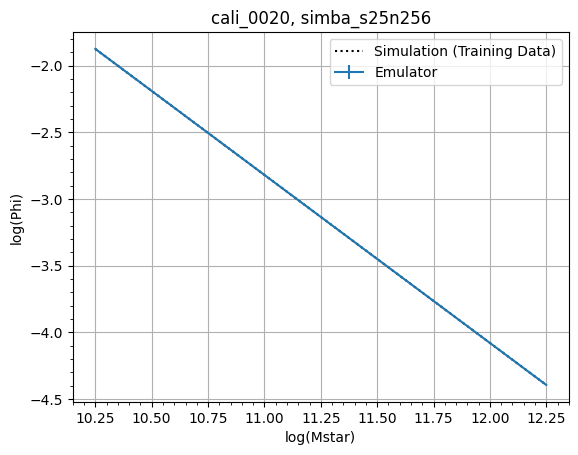

x:  [10.25 12.25]
y:  [-2.02235126 -4.3952632 ]
yerr:  [1.24966704e-12 1.24966704e-12]
Slope:  [-1.1864559650786575]


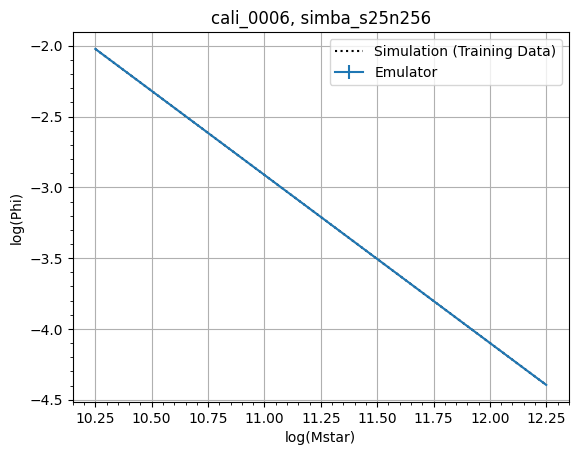

x:  [10.25 12.25]
y:  [-1.79866624 -4.3952632 ]
yerr:  [1.25099930e-12 1.25011113e-12]
Slope:  [-1.2982984781330558]


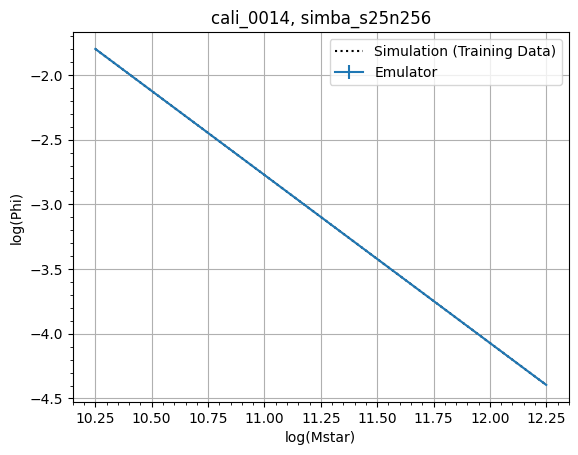

In [29]:
# Make predictions with trained emulator to compare to input

for cali in emulator.model_parameters.model_parameters:
    pred_params = emulator.model_parameters[cali]
    pred_x = emulator.model_values[cali]['independent']
    sim_y = emulator.model_values[cali]['dependent']
    sim_yerr = emulator.model_values[cali]['dependent_error']

    pred_y, pred_var = emulator.predict_values(pred_x, pred_params)
    
    print("x: ", pred_x)
    print("y: ", pred_y)
    print("yerr: ", pred_var)
    print("Slope: ", [(y2-y1)/(x2-x1) for x1, x2, y1, y2 in zip(pred_x[:-1], pred_x[1:], pred_y[:-1], pred_y[1:])])

    plt.clf()
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.title(r'%s, %s' % (cali, snap_prefix))
    plt.grid()
    plt.minorticks_on()
    
    plt.errorbar(pred_x, sim_y, color="black", ls=":", label="Simulation (Training Data)")
#     plt.scatter(pred_x, sim_y, color="black", label="Simulation (Training Data)")
    plt.fill_between(pred_x, sim_y-sim_yerr, sim_y+sim_yerr, color="black", alpha=0.2)
    
    plt.errorbar(pred_x, pred_y, yerr=pred_var, ls='-', label='Emulator')
#     plt.scatter(pred_x, pred_y, label='Emulator')
    plt.legend()
    plt.show()

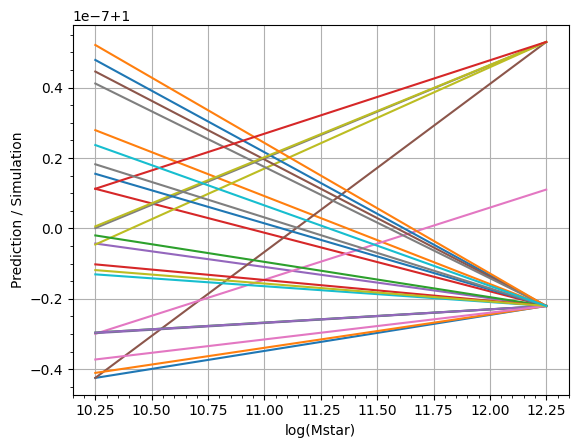

In [30]:
## See how far off each prediction is from its simulation

pred_over_sim_list = []

for cali in emulator.model_parameters.model_parameters:
    pred_params = emulator.model_parameters[cali]
    pred_x = emulator.model_values[cali]['independent']
    sim_y = emulator.model_values[cali]['dependent']

    pred_y, pred_var = emulator.predict_values(pred_x, pred_params)
    
    pred_over_sim = pred_y/sim_y
    pred_over_sim_list = np.append(pred_over_sim_list, pred_over_sim)

    plt.plot(pred_x, pred_over_sim)
#     plt.scatter(pred_x, pred_over_sim)

plt.grid()
plt.minorticks_on()
plt.xlabel(sim_info['X_LABEL'])
plt.ylabel("Prediction / Simulation")
plt.show()

## Parameter sensitivity analysis

In [31]:
# If get division by zero error, it is because there is one (or multiple) emulator(s) that
# have x values that no others have --> need to either re-bin so emulators all have same x
# values, or remove that one point from that emulator
emulator_sensitivities = basic.binwise_sensitivity(specification=emulator.model_specification,
                                                   parameters=emulator.model_parameters,
                                                   values=emulator.model_values)
list(emulator_sensitivities.values())

#tells which of the parameters I changes actaully impact the observable

print(emulator_sensitivities)

{'10.25': array([0.99060723, 0.2491798 , 0.34752765]), '12.25': array([0.55501341, 0.23096593, 0.01360476])}


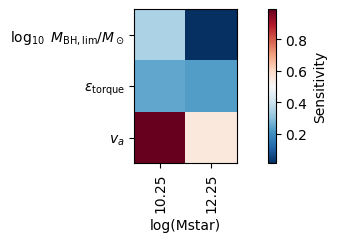

In [32]:
fig, ax = basic.plot_binwise_sensitivity(specification=emulator.model_specification,
                                         sensitivities=emulator_sensitivities,
                                         xlabel=sim_info['X_LABEL'],
                                         cbarlabel='Sensitivity',
                                         vmin=np.nanmin(list(emulator_sensitivities.values())),
                                         vmax=np.nanmax(list(emulator_sensitivities.values())))

# fig.set_size_inches(8, 8, forward=True)
fig.set_size_inches(8, 2, forward=True)

## Perform cross check (validation)

In [33]:
emulator_ccheck = cross_check.CrossCheck(hide_progress=False)
emulator_ccheck.build_emulators(model_specification=model_specification,
                        model_parameters=model_parameters,
                        model_values=model_values)


# 

100%|██████████| 30/30 [00:31<00:00,  1.04s/it]


In [34]:
data_by_cc = emulator_ccheck.build_mocked_model_values_original_independent()

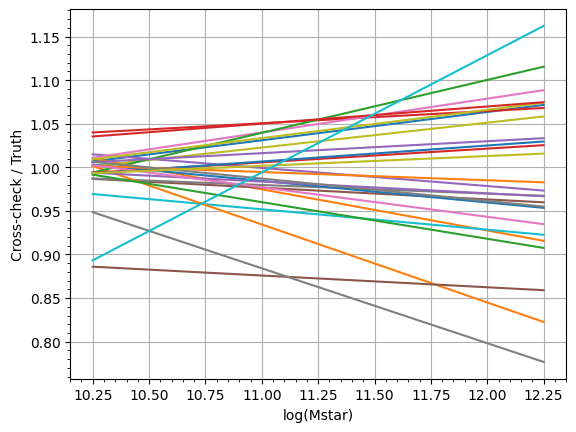

In [35]:
cc_list = []
cc_over_og_list = []

for unique_identifier in emulator_ccheck.model_values.model_values:
    cc_over_og = data_by_cc[unique_identifier]["dependent"] / \
                model_values[unique_identifier]["dependent"]

    cc_list = np.append(cc_list, data_by_cc[unique_identifier]["dependent"])
    cc_over_og_list = np.append(cc_over_og_list, cc_over_og)
    
    plt.plot(data_by_cc[unique_identifier]["independent"], cc_over_og)

plt.grid()
plt.minorticks_on()
plt.xlabel(sim_info['X_LABEL'])
plt.ylabel("Cross-check / Truth")
plt.show()

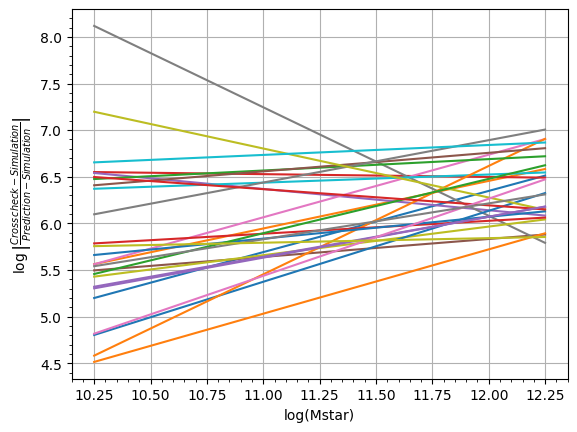

In [36]:
## Cross-check does better if y-axis value is negative (strange, but good. Machine learning is working....?)
## Original prediction does better if y-axis value is positive

pred_list = []

for unique_identifier in emulator_ccheck.model_values.model_values:
    
    pred_params = emulator.model_parameters[unique_identifier]
    pred_x = emulator.model_values[unique_identifier]['independent']
    sim_y = emulator.model_values[unique_identifier]['dependent']

    pred_y, pred_var = emulator.predict_values(pred_x, pred_params)
    
    pred_list = np.append(pred_list, pred_y)
    
    
    val_ = np.log10(np.abs((data_by_cc[unique_identifier]["dependent"] - sim_y)/(pred_y - sim_y)))
    plt.plot(data_by_cc[unique_identifier]["independent"], val_)

plt.grid()
plt.minorticks_on()
plt.xlabel(sim_info['X_LABEL'])
plt.ylabel(r'$\log{ \left| \frac{Cross \, check - Simulation}{Prediction - Simulation} \right|}$')
plt.show()

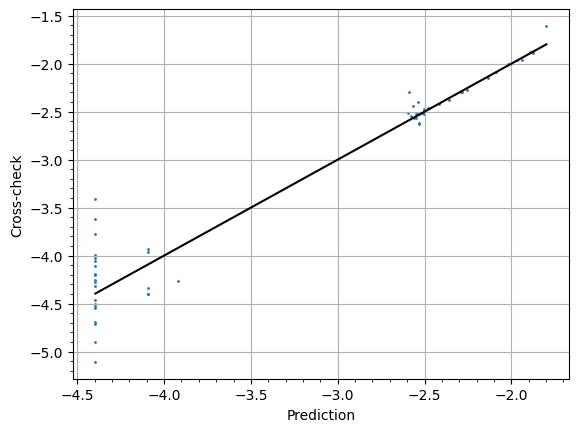

In [37]:
## Second way of comparing the cross-check for each simulation to the prediction as found by
## the fully trained emulator

plt.plot([min(pred_list), max(pred_list)], [min(pred_list), max(pred_list)], color='black')
plt.scatter(pred_list, cc_list, s=1)

plt.grid()
plt.minorticks_on()
plt.xlabel("Prediction")
plt.ylabel("Cross-check")
plt.show()

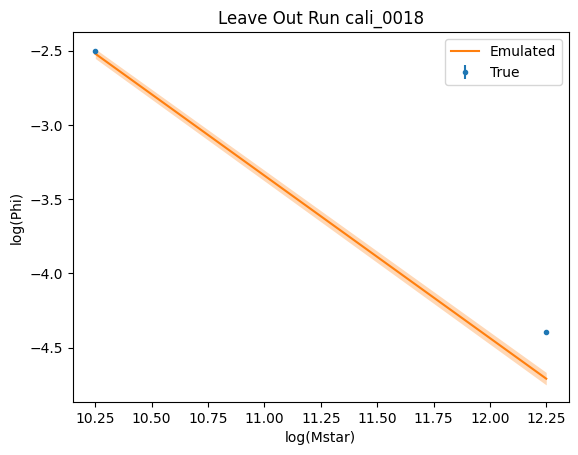

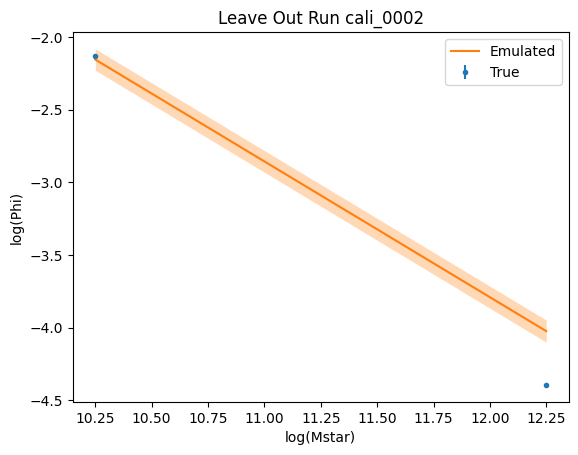

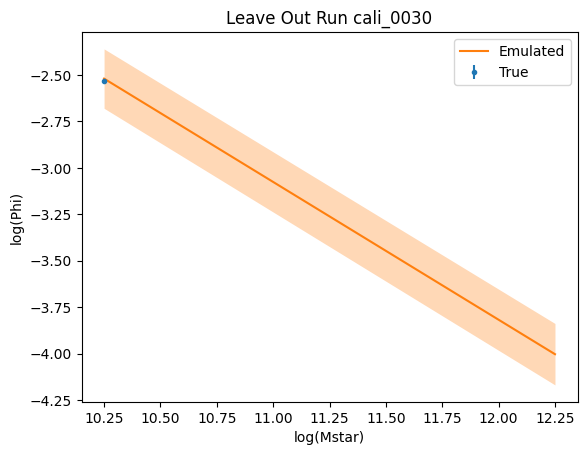

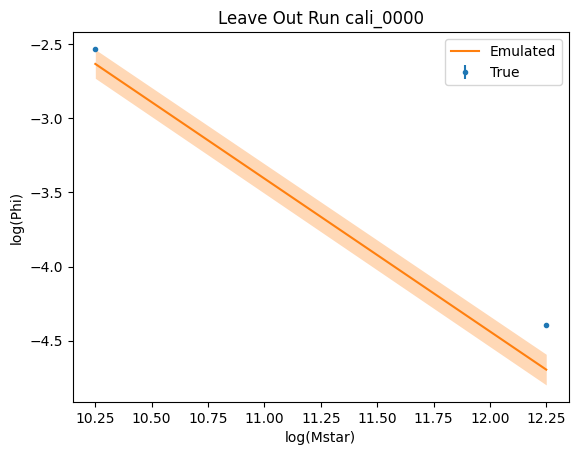

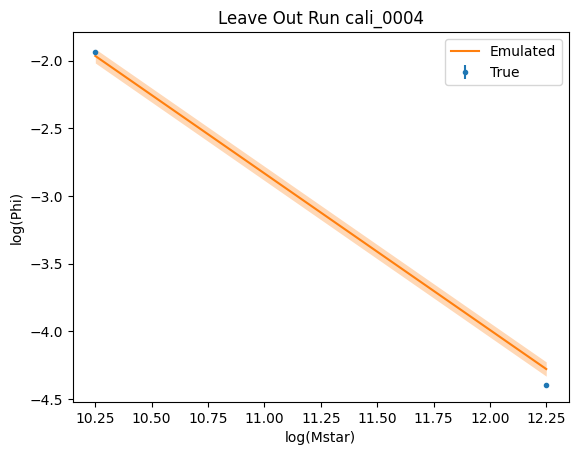

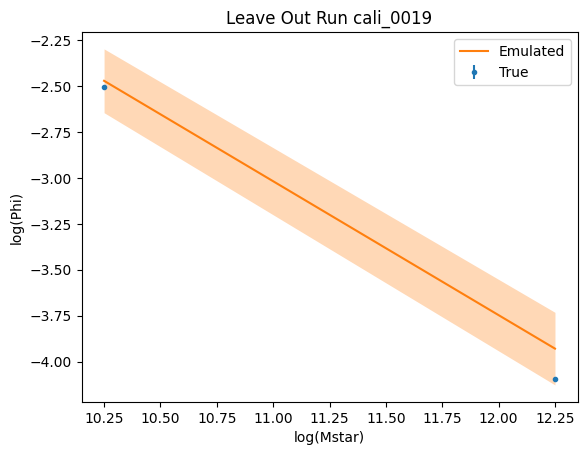

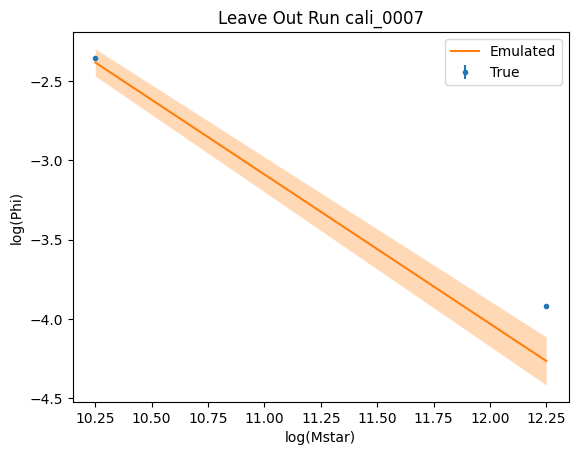

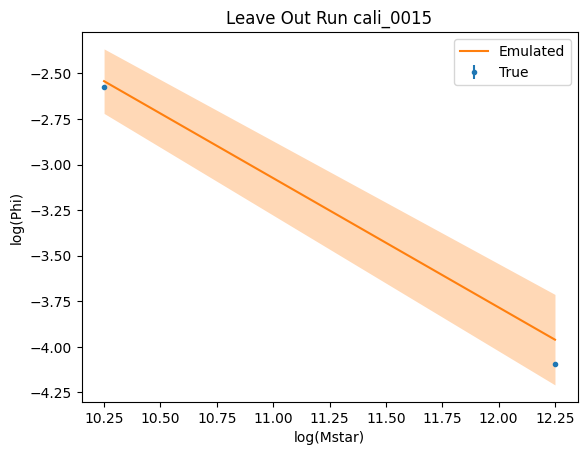

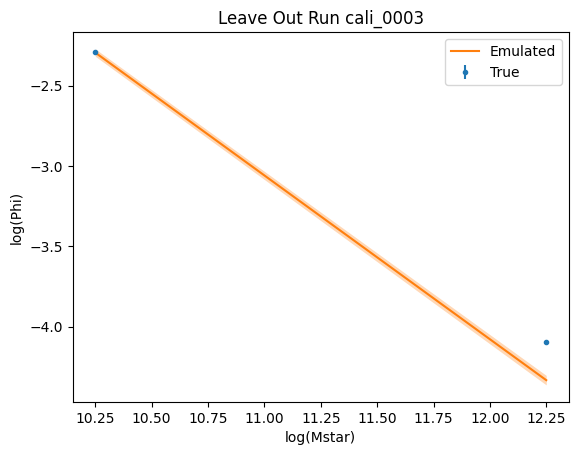

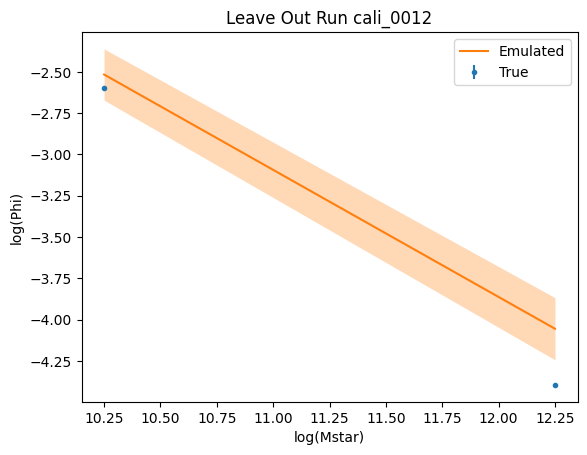

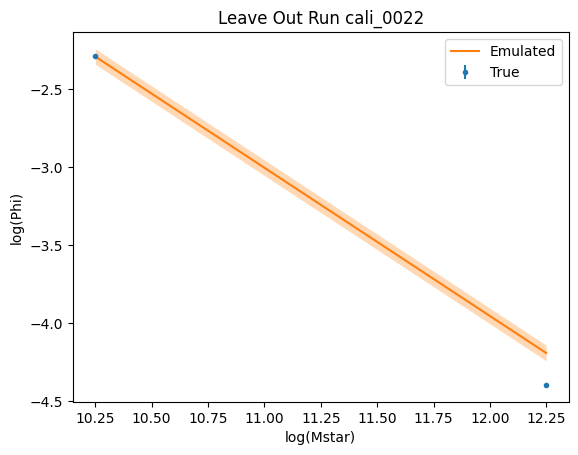

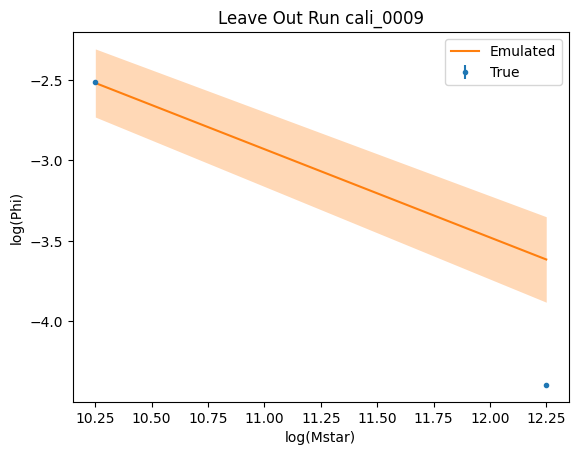

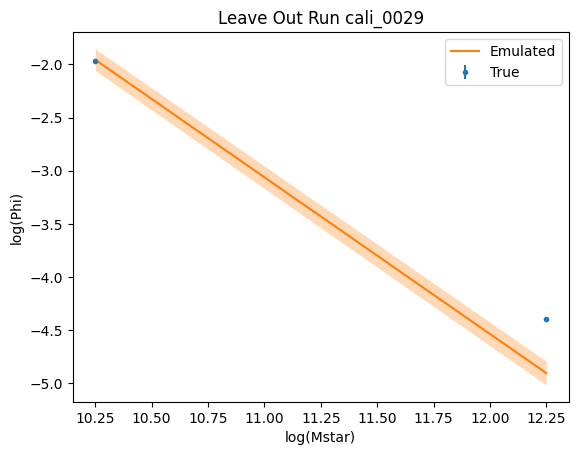

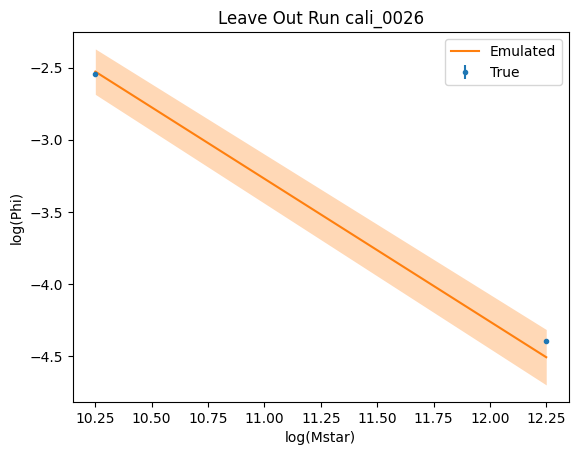

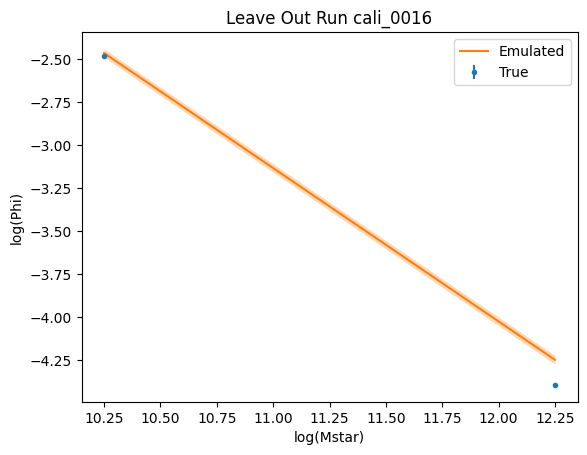

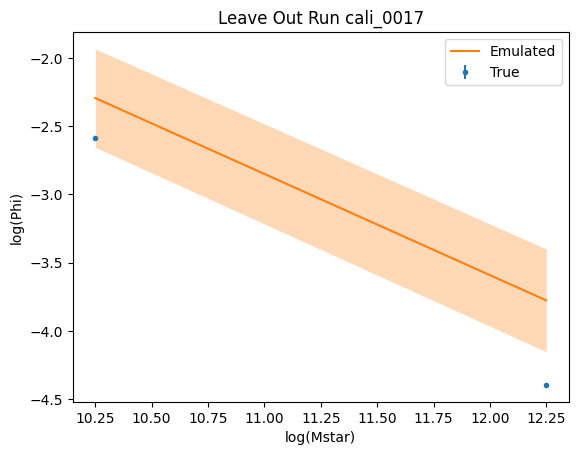

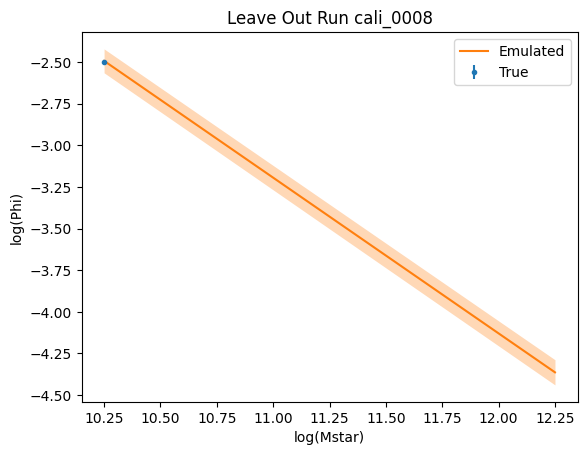

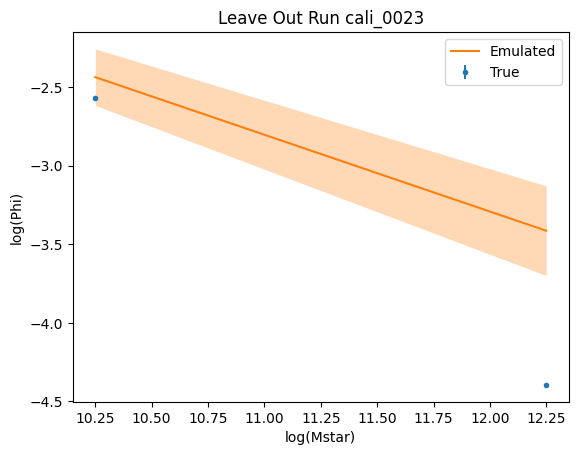

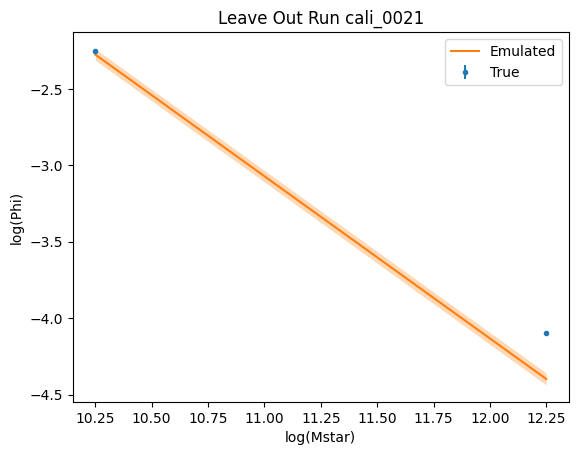

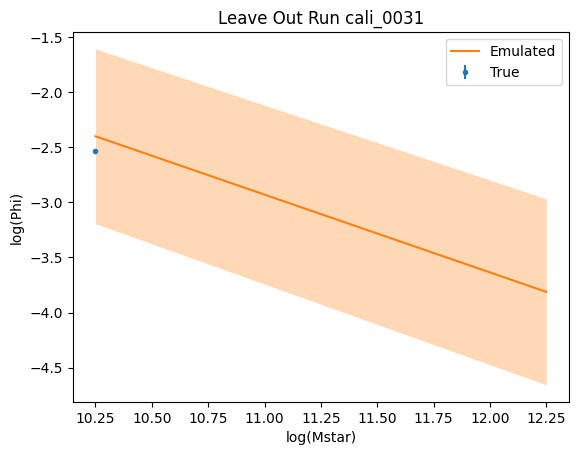

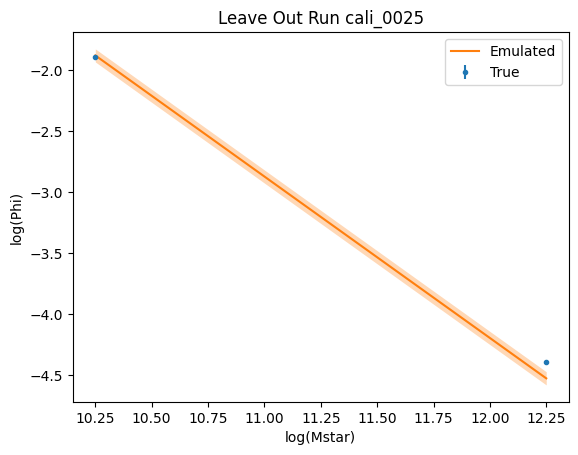

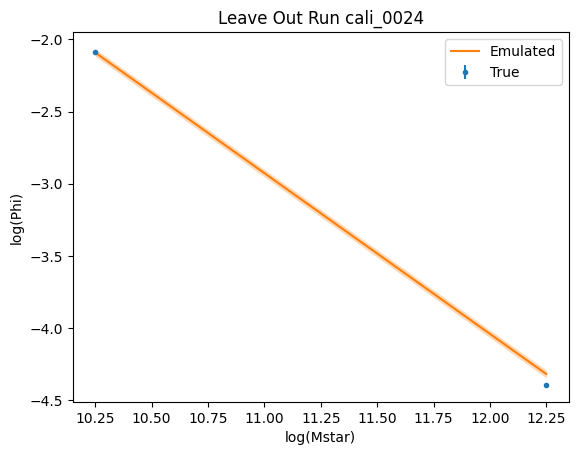

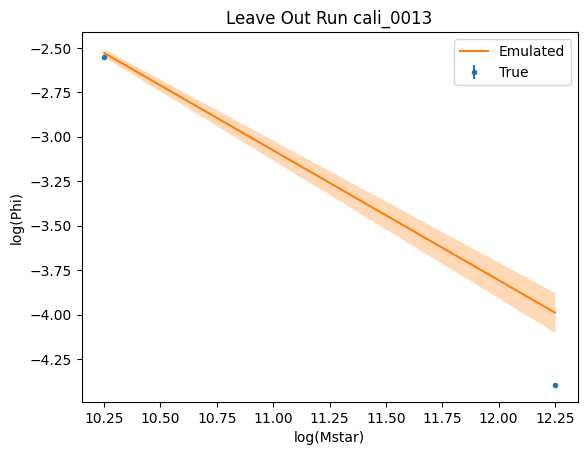

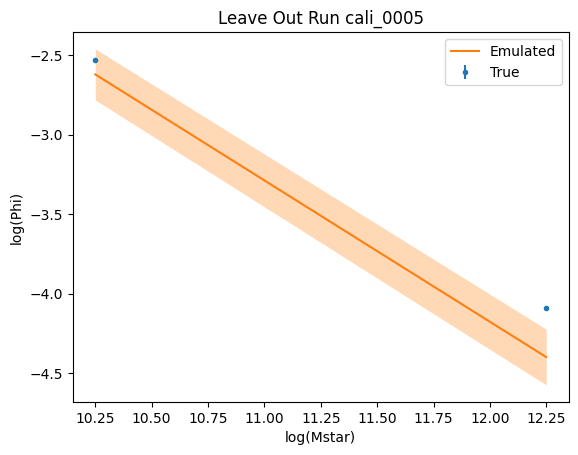

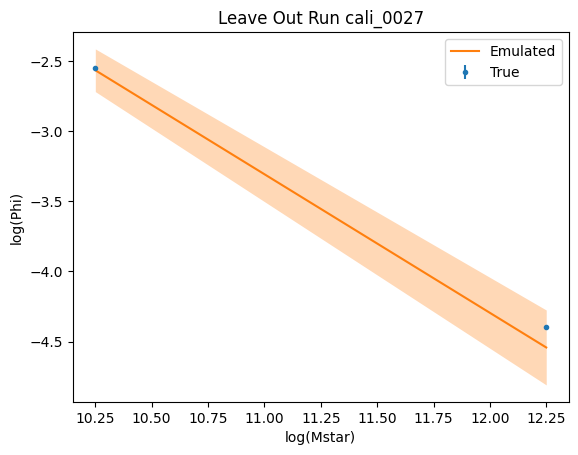

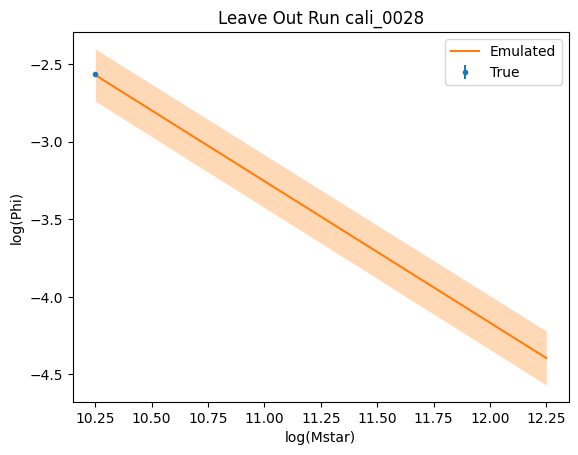

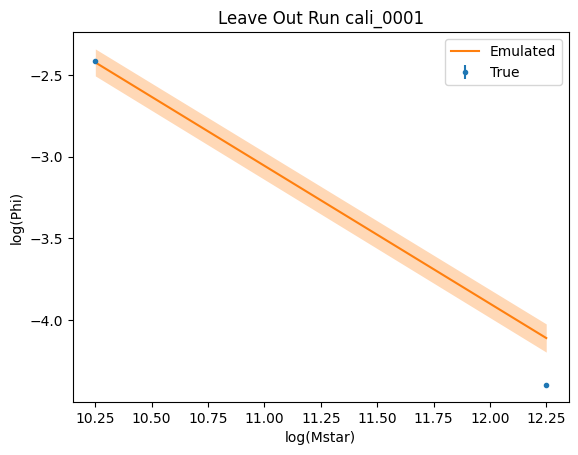

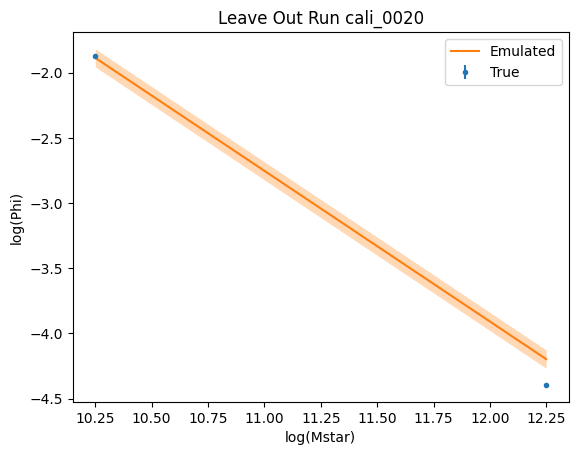

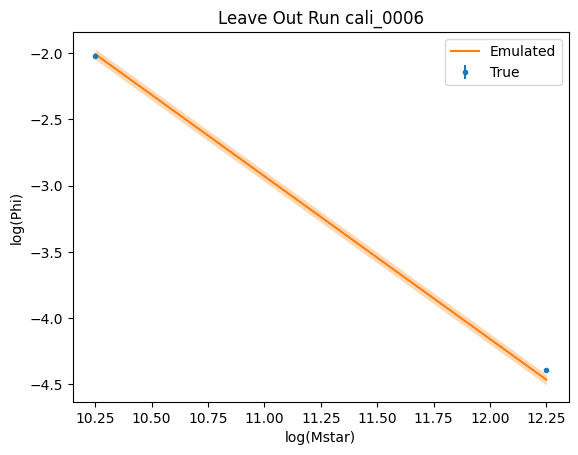

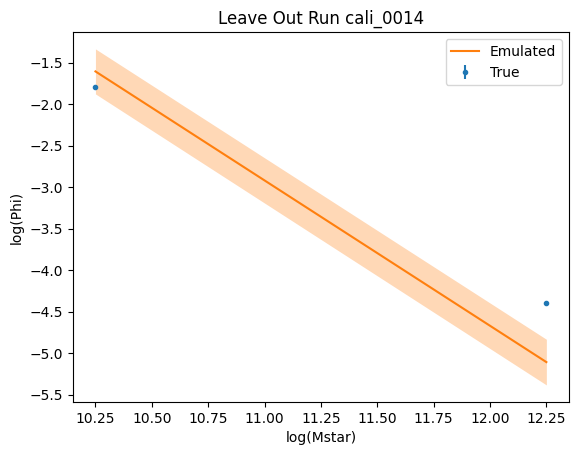

In [38]:
emulator_ccheck.plot_results(emulate_at=data_by_cc[unique_identifier]["independent"],
                         xlabel=sim_info['X_LABEL'],
                         ylabel=sim_info['Y_LABEL'])

In [39]:
total_mean_squared = emulator_ccheck.get_mean_squared()[0]
print("Total mean squared of entire set of left-out simulations: %s" % total_mean_squared)

Total mean squared of entire set of left-out simulations: 0.07474672868608745


In [40]:
## As in FLAMINGO paper (Kugel+22), error on emulator approximated as standard deviation of
## cross-check values divided by original simulation values

# sigma_ccheck = np.nanstd(cc_over_og_list)#, ddof=0)
# sigma_ccheck = total_mean_squared
sigma_ccheck = 0.1 #set to 10 percent error, easiest lol
print('sigma_ccheck =', sigma_ccheck)
emulator.model_specification.sigma_ccheck = sigma_ccheck

sigma_ccheck = 0.1


In [41]:
def emulator_model(x, pred_params, emulator):
    pred_y, pred_var = emulator.predict_values(x, pred_params)
    
    pred_std = np.sqrt(pred_var)
    pred_ccheck_std = np.abs(emulator.model_specification.sigma_ccheck * pred_y)
    pred_total = np.sqrt(pred_std**2 + pred_ccheck_std**2)
    
    return pred_y, pred_ccheck_std

x:  [10.25 12.25]
pred_y:  [-2.50316858 -4.3952632 ]
pred_yerr:  [0.25031686 0.43952632]


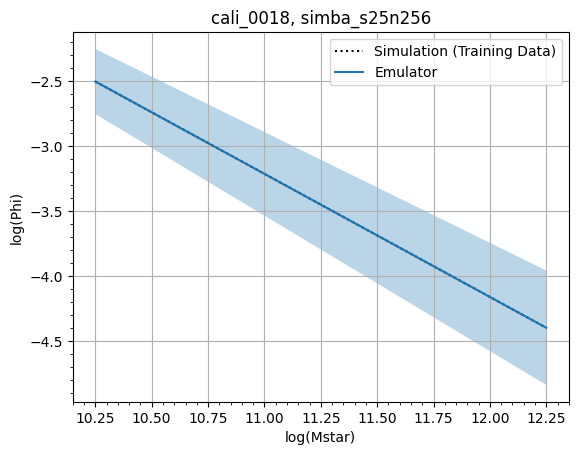

x:  [10.25 12.25]
pred_y:  [-2.13281226 -4.3952632 ]
pred_yerr:  [0.21328123 0.43952632]


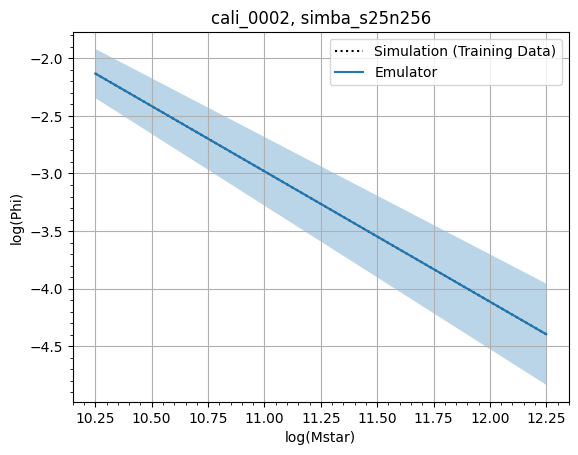

x:  [10.25]
pred_y:  [-2.53194046]
pred_yerr:  [0.25319405]


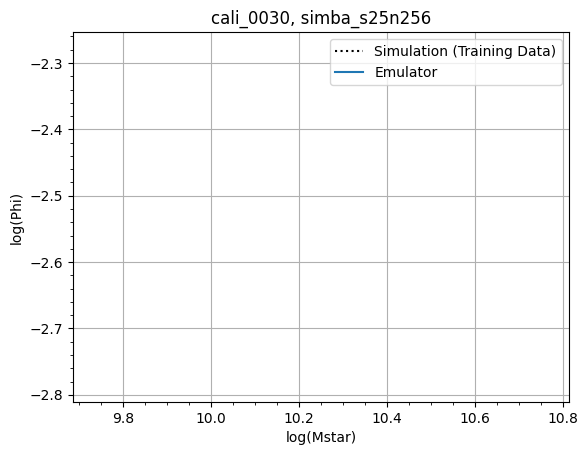

x:  [10.25 12.25]
pred_y:  [-2.53194046 -4.3952632 ]
pred_yerr:  [0.25319405 0.43952632]


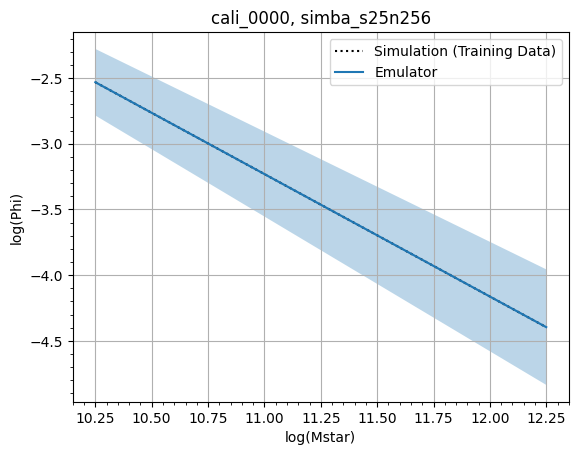

x:  [10.25 12.25]
pred_y:  [-1.93738139 -4.39526319]
pred_yerr:  [0.19373814 0.43952632]


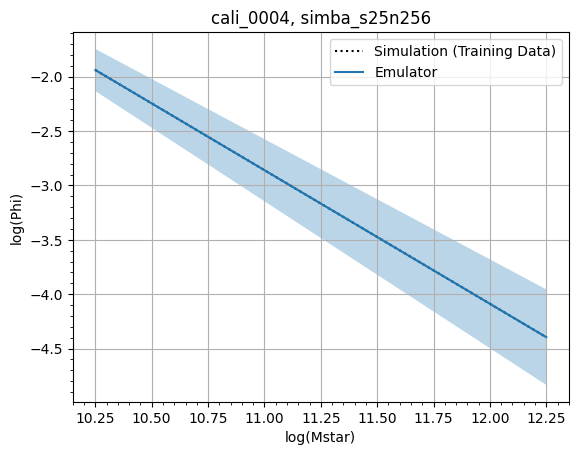

x:  [10.25 12.25]
pred_y:  [-2.50316858 -4.09423351]
pred_yerr:  [0.25031686 0.40942335]


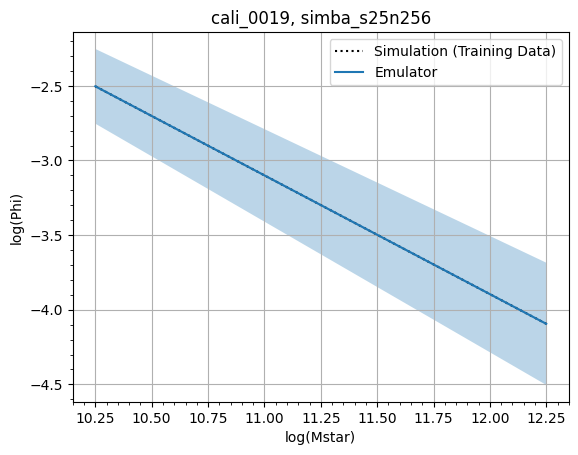

x:  [10.25 12.25]
pred_y:  [-2.35783672 -3.91814208]
pred_yerr:  [0.23578367 0.39181421]


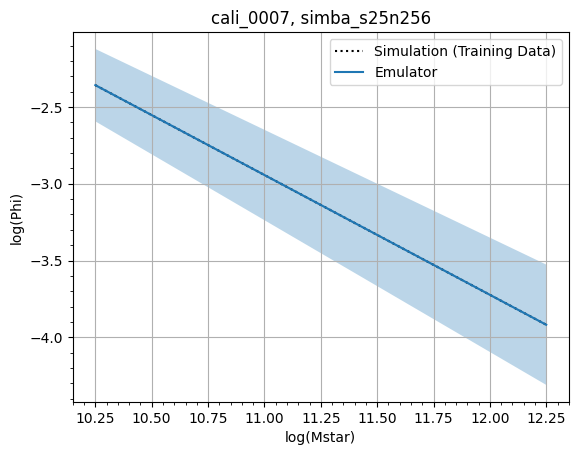

x:  [10.25 12.25]
pred_y:  [-2.57571936 -4.09423351]
pred_yerr:  [0.25757194 0.40942335]


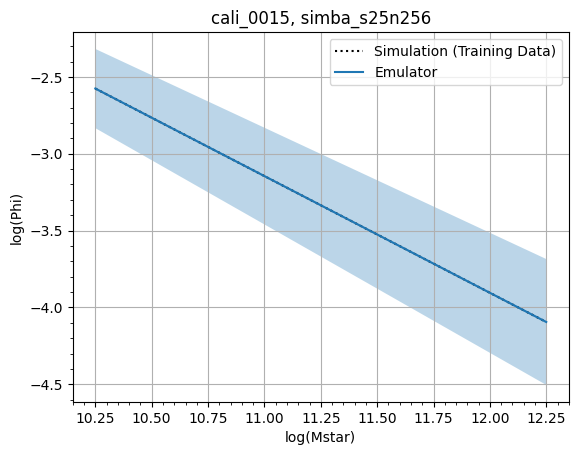

x:  [10.25 12.25]
pred_y:  [-2.29145956 -4.09423351]
pred_yerr:  [0.22914596 0.40942335]


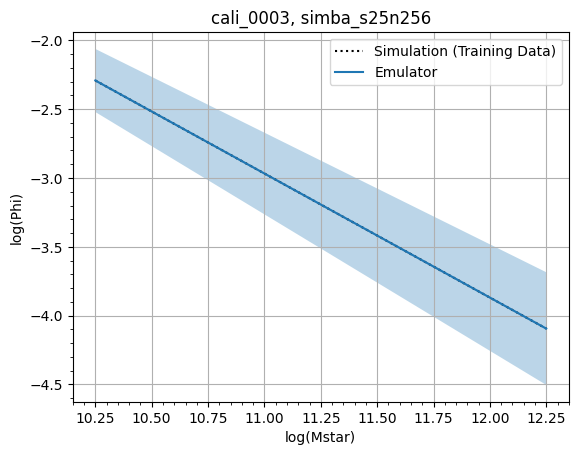

x:  [10.25 12.25]
pred_y:  [-2.59592271 -4.3952632 ]
pred_yerr:  [0.25959227 0.43952632]


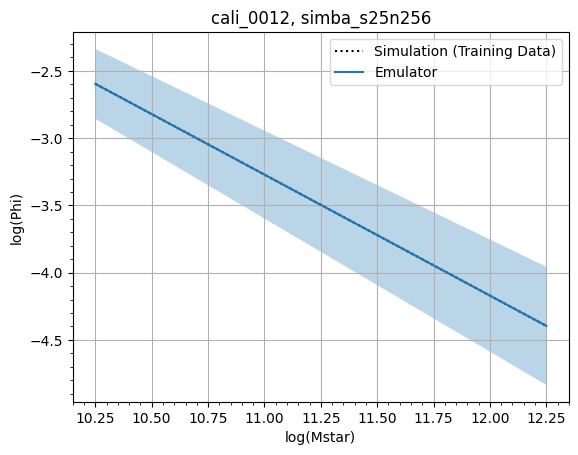

x:  [10.25 12.25]
pred_y:  [-2.28467369 -4.3952632 ]
pred_yerr:  [0.22846737 0.43952632]


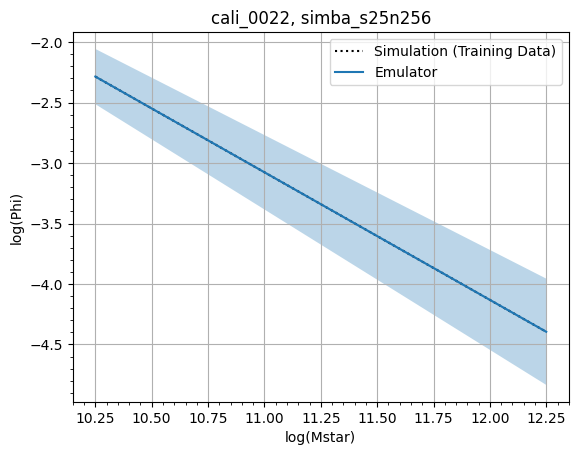

x:  [10.25 12.25]
pred_y:  [-2.5144496 -4.3952632]
pred_yerr:  [0.25144496 0.43952632]


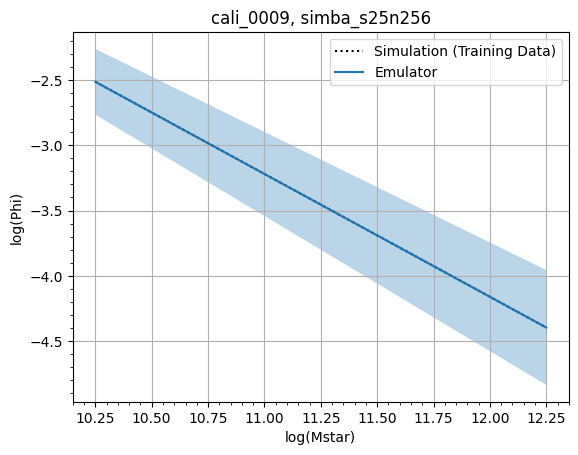

x:  [10.25 12.25]
pred_y:  [-1.96875203 -4.3952632 ]
pred_yerr:  [0.1968752  0.43952632]


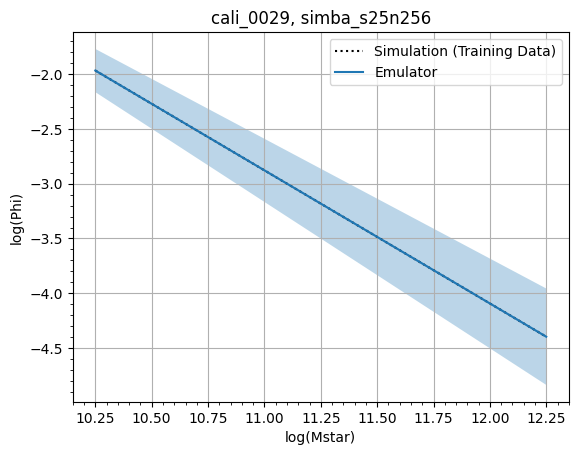

x:  [10.25 12.25]
pred_y:  [-2.54400492 -4.3952632 ]
pred_yerr:  [0.25440049 0.43952632]


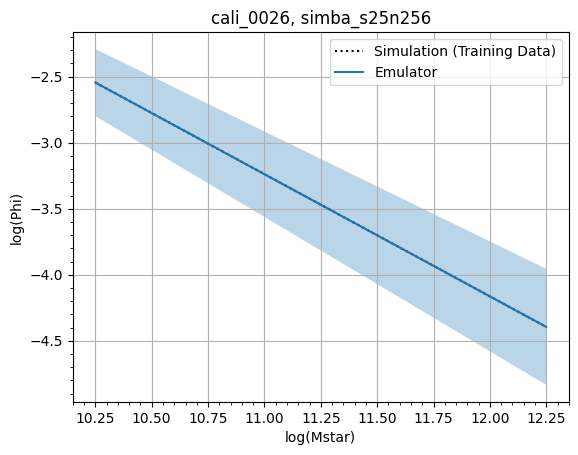

x:  [10.25 12.25]
pred_y:  [-2.48144937 -4.39526319]
pred_yerr:  [0.24814494 0.43952632]


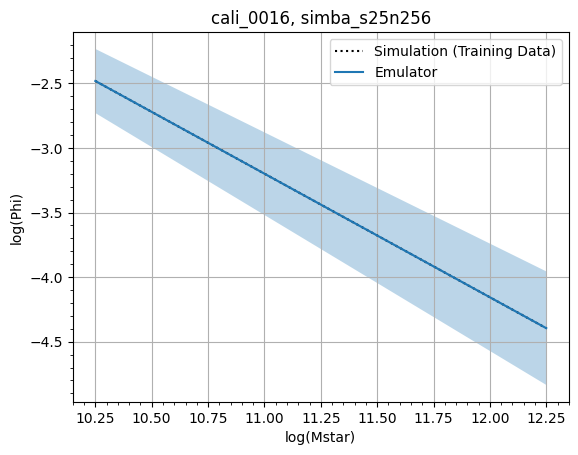

x:  [10.25 12.25]
pred_y:  [-2.58908343 -4.3952632 ]
pred_yerr:  [0.25890834 0.43952632]


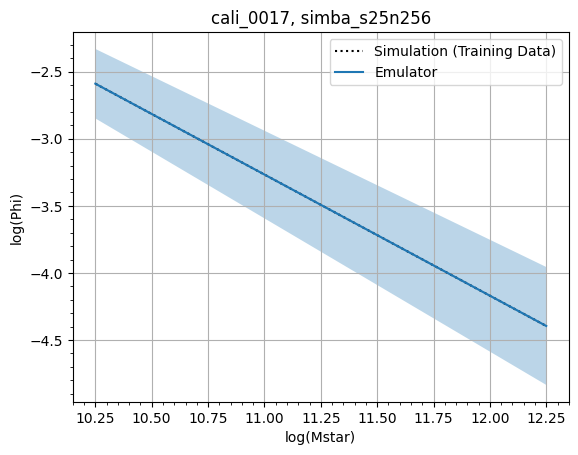

x:  [10.25]
pred_y:  [-2.50316858]
pred_yerr:  [0.25031686]


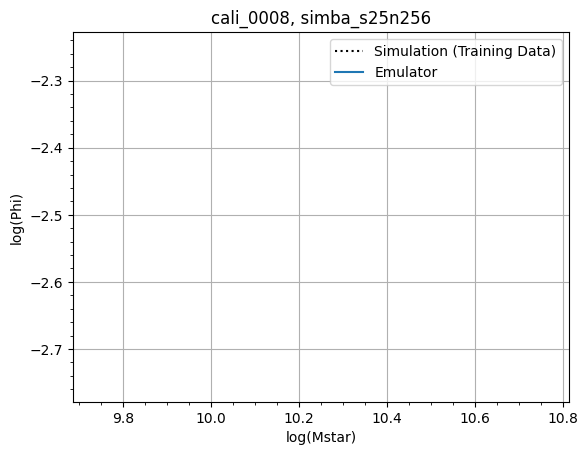

x:  [10.25 12.25]
pred_y:  [-2.56918859 -4.3952632 ]
pred_yerr:  [0.25691886 0.43952632]


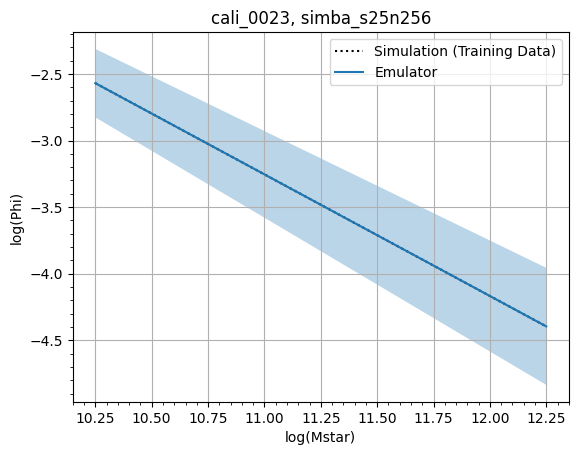

x:  [10.25 12.25]
pred_y:  [-2.25538421 -4.09423351]
pred_yerr:  [0.22553842 0.40942335]


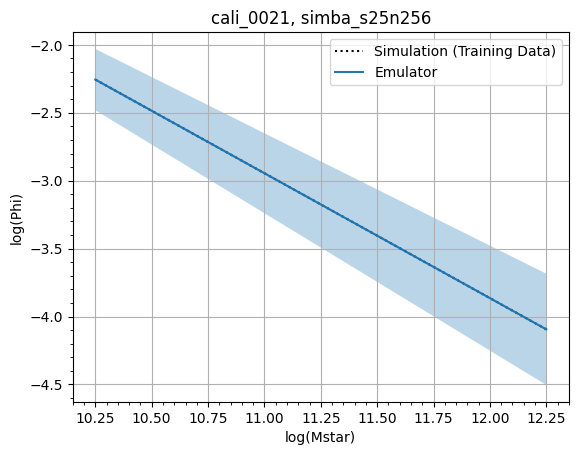

x:  [10.25]
pred_y:  [-2.53793073]
pred_yerr:  [0.25379307]


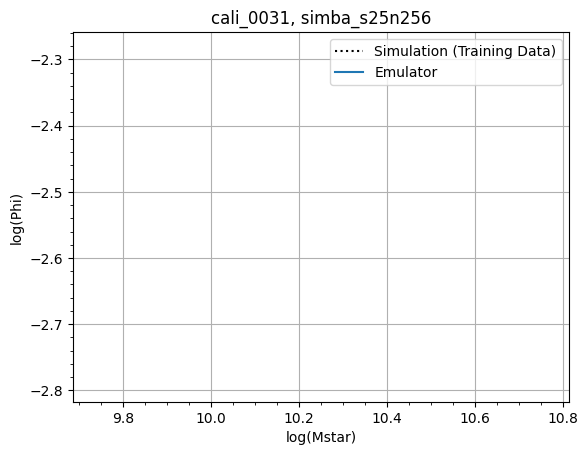

x:  [10.25 12.25]
pred_y:  [-1.89557624 -4.3952632 ]
pred_yerr:  [0.18955762 0.43952632]


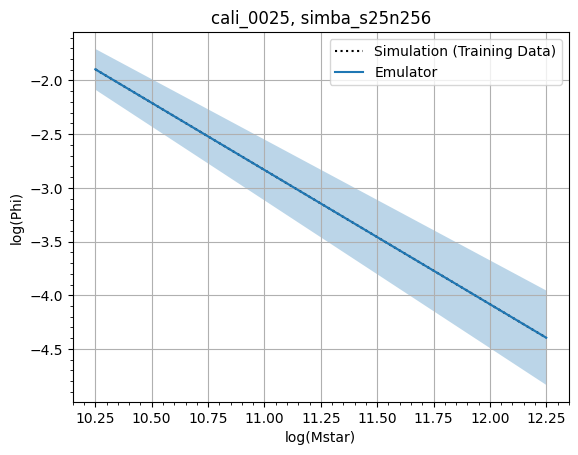

x:  [10.25 12.25]
pred_y:  [-2.08776736 -4.39526319]
pred_yerr:  [0.20877674 0.43952632]


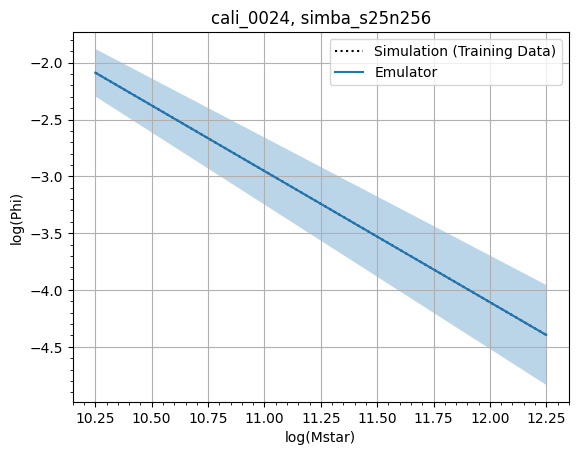

x:  [10.25 12.25]
pred_y:  [-2.55016518 -4.3952632 ]
pred_yerr:  [0.25501652 0.43952632]


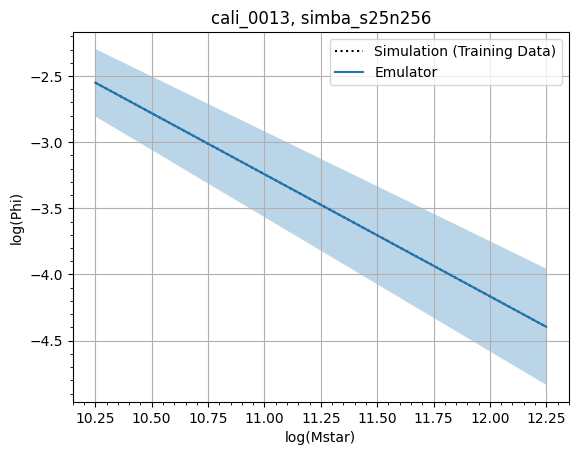

x:  [10.25 12.25]
pred_y:  [-2.53194046 -4.09423351]
pred_yerr:  [0.25319405 0.40942335]


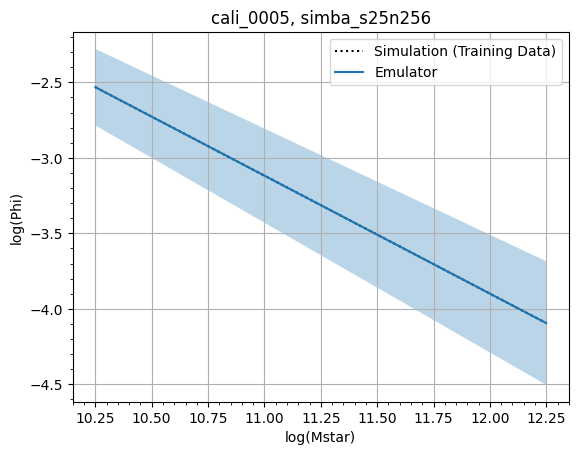

x:  [10.25 12.25]
pred_y:  [-2.55016518 -4.3952632 ]
pred_yerr:  [0.25501652 0.43952632]


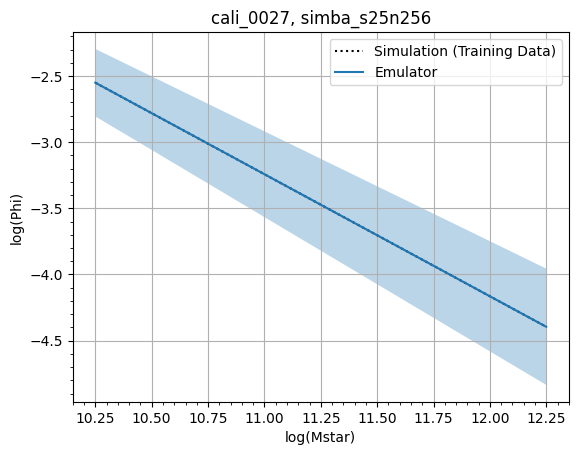

x:  [10.25]
pred_y:  [-2.56275439]
pred_yerr:  [0.25627544]


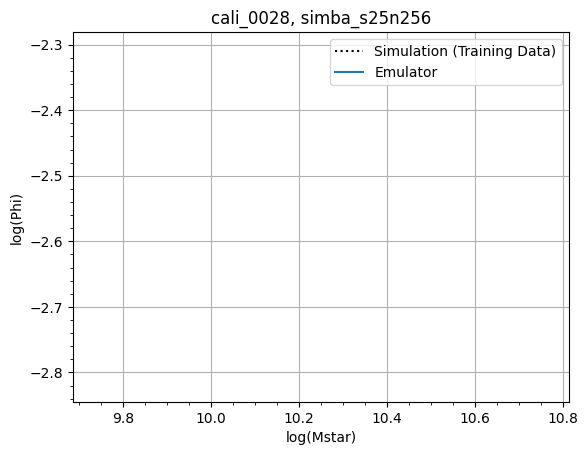

x:  [10.25 12.25]
pred_y:  [-2.4175396 -4.3952632]
pred_yerr:  [0.24175396 0.43952632]


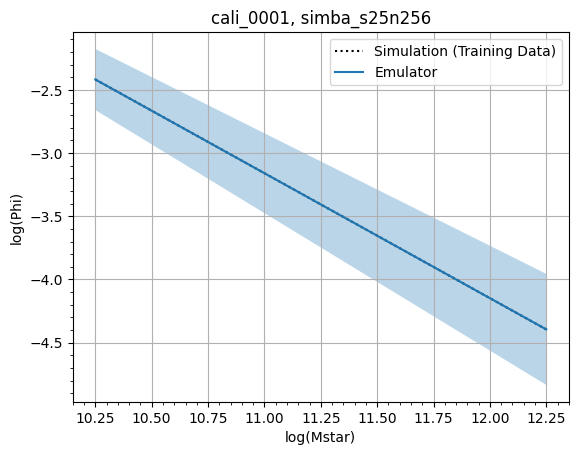

x:  [10.25 12.25]
pred_y:  [-1.87412524 -4.39526319]
pred_yerr:  [0.18741252 0.43952632]


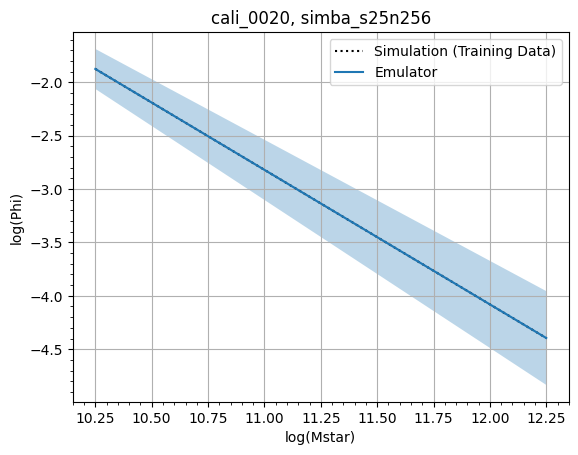

x:  [10.25 12.25]
pred_y:  [-2.02235126 -4.3952632 ]
pred_yerr:  [0.20223513 0.43952632]


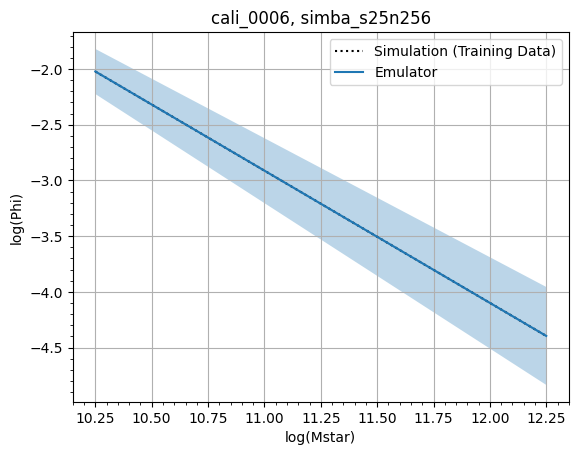

x:  [10.25 12.25]
pred_y:  [-1.79866624 -4.3952632 ]
pred_yerr:  [0.17986662 0.43952632]


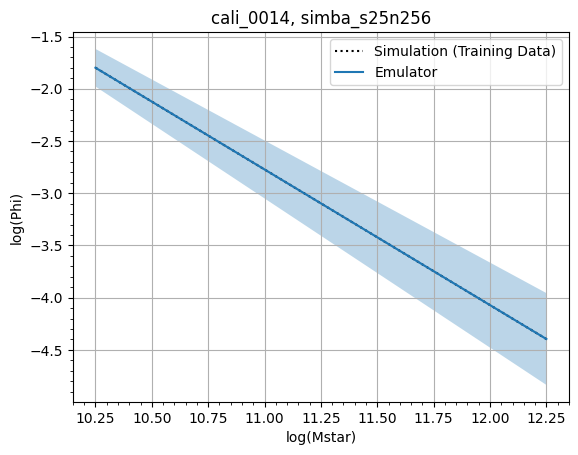

In [42]:
# Make predictions with trained emulator (but now with emulator uncertainties!) to compare to input

for cali in emulator.model_parameters.model_parameters:
    pred_params = emulator.model_parameters[cali]
    pred_x = emulator.model_values[cali]['independent']
    sim_y = emulator.model_values[cali]['dependent']
    sim_yerr = emulator.model_values[cali]['dependent_error']
    
    pred_y, pred_err = emulator_model(pred_x, pred_params, emulator)

    print("x: ", pred_x)
    print("pred_y: ", pred_y)
    print("pred_yerr: ", pred_err) 

    plt.clf()
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.title(r'%s, %s' % (cali, snap_prefix))
    plt.grid()
    plt.minorticks_on()
    
#     plt.errorbar(pred_x, sim_y, yerr=sim_yerr, color="black", ls=":", label="Simulation (Training Data)")
    plt.errorbar(pred_x, sim_y, color="black", ls=":", label="Simulation (Training Data)")
#     plt.scatter(pred_x, sim_y, color="black", label="Simulation (Training Data)")
    plt.fill_between(pred_x, sim_y-sim_yerr, sim_y+sim_yerr, color='black', alpha=0.2)

#     plt.errorbar(pred_x, pred_y, yerr=pred_err, ls='-', fmt='o', label='Emulator')
    plt.errorbar(pred_x, pred_y, yerr=None, ls='-', label='Emulator')
#     plt.scatter(pred_x, pred_y, label='Emulator')
    plt.fill_between(pred_x, pred_y-pred_err, pred_y+pred_err, alpha=0.3)
    plt.legend()
    plt.show()

## Sweeps of parameter space

In [43]:
# Get full range of x values that have been used in training emulator

#another way of checking parameter sensitivity

sim_x = []
for cali in emulator.model_values.model_values:
    sim_x_curr = emulator.model_values[cali]['independent']
    for x_val in sim_x_curr:
        if x_val not in sim_x:
            sim_x.append(x_val)
            
sim_x = np.array(np.sort(sim_x))
print(sim_x)

[10.25 12.25]


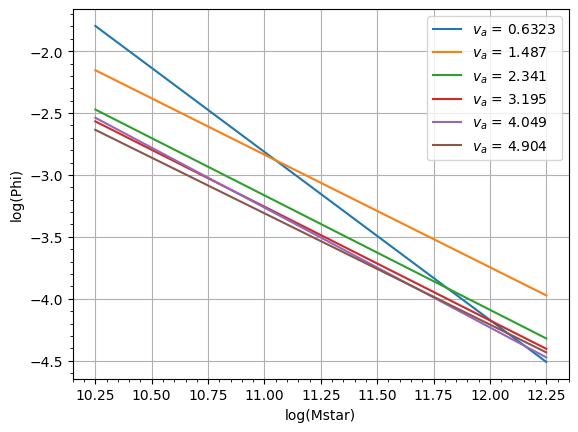

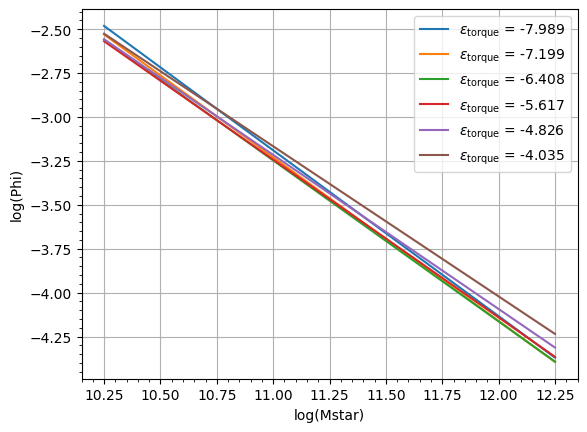

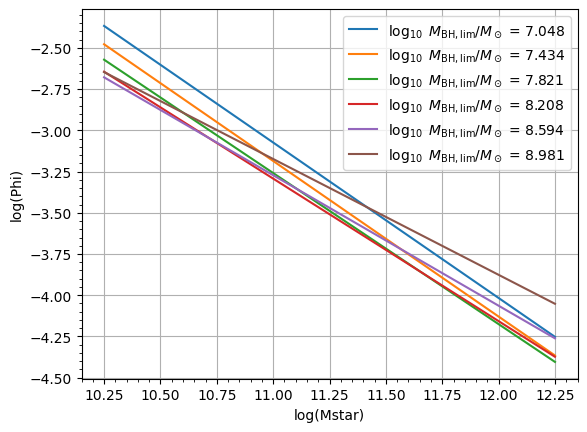

In [44]:
# Arbitrarily choose initial parameters to sweep from
# Doesn't matter too much though, because it ends up covering
# roughly the entire range of parameters used

centre = emulator.model_parameters['cali_0000']

for ii in range(len(emulator.parameter_order)):
    param_name = emulator.parameter_order[ii]
    param_printable_name = emulator.model_specification.parameter_printable_names[ii]
    
    Mock_values, Mock_parameters = mock_sweep(emulator, emulator.model_specification, 6, param_name, centre)

    plt.clf()
    
    for mock_name in Mock_values.keys():
        plt.plot(Mock_values[mock_name]["independent"],
                Mock_values[mock_name]["dependent"],
                label = "%s = %.4g" % (param_printable_name, Mock_parameters[mock_name][param_name]))
#         plt.scatter(Mock_values[mock_name]["independent"],
#                 Mock_values[mock_name]["dependent"],
#                 label = "%s = %.4g" % (param_printable_name, Mock_parameters[mock_name][param_name]))
    
    plt.xlabel(sim_info['X_LABEL'])
    plt.ylabel(sim_info['Y_LABEL'])
    plt.grid()
    plt.minorticks_on()
    plt.legend()
    plt.show()

## Checking hyperparameters (doesn't always work)

In [45]:
emulator.kernel.get_parameter_dict(include_frozen=True)

OrderedDict([('k1:log_constant', -1.3862943611198906),
             ('k2:metric:log_M_0_0', 0.0),
             ('k2:metric:log_M_1_1', 0.0),
             ('k2:metric:log_M_2_2', 0.0),
             ('k2:metric:log_M_3_3', 0.0)])

In [46]:
emulator_mcmc = gaussian_process_mcmc.GaussianProcessEmulatorMCMC(burn_in_steps=1, mcmc_steps=1000)#, hide_progress=False)
emulator_mcmc.fit_model(model_specification=model_specification,
                        model_parameters=model_parameters,
                        model_values=model_values)

emcee: Exception while calling your likelihood function:
  params: [ 1.26787283e+00 -8.05413102e+02 -2.33047738e-01  5.68885744e+00
  2.03361321e+00]
  args: []
  kwargs: {}
  exception:


Traceback (most recent call last):
  File "/gpfs/fs1/home/b/babul/stlock/swift/swift_venv/lib/python3.11/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gpfs/fs1/home/b/babul/stlock/swift/swift_venv/src/swiftemulator/swiftemulator/emulators/gaussian_process_mcmc.py", line 249, in log_likelihood
    return -negative_log_likelihood(p)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gpfs/fs1/home/b/babul/stlock/swift/swift_venv/src/swiftemulator/swiftemulator/emulators/gaussian_process_mcmc.py", line 242, in negative_log_likelihood
    return -gaussian_process.log_likelihood(self.dependent_variables)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gpfs/fs1/home/b/babul/stlock/swift/swift_venv/lib/python3.11/site-packages/george/gp.py", line 385, in log_likelihood
    if not self.recompute(quiet=quiet):
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File

ValueError: array must not contain infs or NaNs

In [ ]:
emulator_mcmc.kernel.get_parameter_dict(include_frozen=True)

In [ ]:
emulator_mcmc.plot_hyperparameter_distribution()

## Save emulator to pickle file with dill module

In [47]:
def save_object(obj, filename):
    with open(filename, 'wb') as f:  # Overwrites any existing file.
        dill.dump(obj, f, dill.HIGHEST_PROTOCOL)

In [48]:
emulator_filename = 'emulator_'+obs_name+'.pkl'
emulator_path = os.path.join(root_dir, 'emulators')
if not os.path.isdir(emulator_path):
    os.makedirs(emulator_path, mode = 0o755, exist_ok=True)
save_object(emulator, os.path.join(emulator_path, emulator_filename))